In [19]:
import numpy as np
import pandas as pd

from pyboat import ensemble_measures as em
from pyboat import WAnalyzer, ssg
from pyboat import plotting as pl

import scipy.signal
import pywt

import matplotlib.pyplot as plt

import bokeh_catplot
from bokeh.plotting import figure, show
from bokeh.models import FactorRange, Button, ColumnDataSource, HoverTool, TapTool, Slider, Select, Span, BoxZoomTool

import bokeh.io

import iqplot

bokeh.io.output_notebook()

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


Loading BokehJS ...

In [20]:
cd H:/PROJECTS-03/Pablo/oscillating/ppf019/

H:\PROJECTS-03\Pablo\oscillating\ppf019


In [23]:
notebook_url = 'localhost:8888'

In [24]:
def analyze_signal(signals, df_fouriers, wAn, save_path=None, plot=False):
    for signal in signals.columns:
        signals[signal] = wAn.sinc_detrend(signals[signal], T_c = 275)
        wAn.compute_spectrum(signals[signal], do_plot=plot)
        if plot == True:
            plt.title(signal)
        df_fouriers[signal] = wAn.get_averaged_spectrum()
        if save_path is not None:
            plt.savefig(fname=save_path+signal)
    return df_fouriers

In [25]:
def plot_fourier(freq_domain, signal, peak, y_value):
    x = freq_domain
    y = signal
    plt.plot(x, y)
    plt.xlim(np.min(x), np.max(x))
    plt.xlabel('Freq (min)')
    plt.ylabel('Power')
    plt.plot(peak, y_value, marker="x", markersize=5, markeredgecolor="red", markerfacecolor="red")    

In [26]:
def process_peaks(df_fouriers, freq_domain, cut_off=130, peak_prom=0.50):
    max_peak = []
    name_signal = []
    non_processed = []
    for f_signal in df_fouriers.columns:
        try:
            # peak = freq_domain[np.max(scipy.signal.find_peaks(df_fouriers[f_signal], prominence=peak_prom, height=1, width=5)[0])]
            peak = freq_domain[np.min(scipy.signal.find_peaks(df_fouriers[f_signal], prominence=peak_prom, height=1)[0])]
            if peak < cut_off: 
                max_peak.append(peak)
                name_signal.append(f_signal)
        except ValueError:
            print(f'Cannot find peak for {f_signal}')
            non_processed.append(f_signal)
    return np.array(max_peak, dtype=np.float32), name_signal, non_processed

In [27]:
def check_peaks(signals, peaks, df_fouriers, agg=False, med_mean = False, title=None):
    for signal, peak in zip(signals, peaks):
        freq_domain = df_fouriers.index
        closest_value = min(df_fouriers_control.index, key=lambda x: abs(peak - x))
        y_value = df_fouriers.loc[closest_value, signal]
        plot_fourier(freq_domain, df_fouriers[signal], peak, y_value)
        if agg==True:
            plt.ylim(0,8)
            plt.yticks(ticks=range(0, 13, 1), labels=map(str, range(0, 13 , 1)))
        else:
            plt.title(signal)
            plt.show()

    if agg == True:
        plt.title(title)
        if med_mean==True:
            plt.axvline(x = np.mean(peaks), color ='b')
            plt.axvline(x = np.median(peaks), color ='r')
            plt.show()
        else:
            plt.show()

In [9]:
def normalize_df(dataframe):
    normalized_dataframe = dataframe.copy()
    for column in dataframe.columns.values:
        normalized_dataframe[column] = (normalized_dataframe[column] - normalized_dataframe[column].min()) / (normalized_dataframe[column].max() - normalized_dataframe[column].min())  
    return normalized_dataframe

In [28]:
df_total = pd.read_csv('./valid_signals_interpolated_ppf019', index_col=0)

In [29]:
df_total

,ppf019_xy001_0,ppf019_xy002_0,ppf019_xy003_0,ppf019_xy005_0,ppf019_xy006_0,ppf019_xy006_1,ppf019_xy007_0,ppf019_xy008_0,ppf019_xy009_0,ppf019_xy012_0,...,ppf019_xy088_0,ppf019_xy089_0,ppf019_xy091_1,ppf019_xy092_0,ppf019_xy093_0,ppf019_xy094_0,ppf019_xy097_0,ppf019_xy098_0,ppf019_xy099_0,ppf019_xy100_0
0,892.521945,918.811594,901.305423,826.795687,887.433803,919.460020,954.910145,854.599801,936.901747,898.724798,...,920.145022,910.063730,956.739232,931.360401,958.857143,949.317298,814.119048,865.643221,1045.761146,867.557464
1,940.044525,968.236449,916.120202,840.065060,902.771194,918.122824,963.334305,864.076137,968.423556,908.777448,...,929.244541,955.229035,934.913491,948.835185,952.614961,990.054945,839.010514,894.787118,1114.072000,965.463479
2,1154.257653,1129.660232,915.241379,852.773606,910.023946,923.447262,955.188318,872.040474,942.468317,924.381905,...,919.466327,1011.219178,975.209850,967.008174,972.143692,1016.154788,827.027053,877.330401,1065.797101,1021.568627
3,1317.167336,1177.788191,921.605911,846.754470,886.936979,924.918977,936.498413,876.458293,935.669065,959.302488,...,915.188293,1033.303670,1001.472901,913.084507,988.479951,1062.044444,846.252725,906.412088,1054.055000,1071.233716
4,1285.092326,1185.286686,910.385016,852.670945,860.376335,861.831230,895.369755,854.114094,902.333333,952.670294,...,941.160643,1019.590119,977.278978,958.309751,1014.685552,975.884324,851.675497,904.769147,1012.265269,1119.719247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,848.406646,856.794118,864.534642,842.888073,859.452899,807.549125,859.031856,873.401945,905.312187,941.846626,...,3214.437059,1759.123320,2143.854197,1632.885291,1432.363929,1848.201446,2554.095146,1104.317337,1361.535445,953.966457
69,852.964339,867.954044,859.779923,827.344411,864.500000,809.722359,859.586381,878.070890,915.873239,931.396114,...,3244.686520,1816.621454,2129.616564,1678.086395,1415.138614,1817.782117,2765.069159,1117.215531,1344.655502,949.032823
70,845.925645,849.367498,856.771008,832.376083,863.256109,812.612517,849.698667,860.559295,916.550082,928.810030,...,3108.481444,1834.077193,2062.826648,1641.210428,1415.478261,1962.462617,3011.483444,1107.325509,1366.945038,929.428571
71,839.070381,857.508036,869.680604,814.824806,856.252641,798.113341,851.050602,873.452693,899.755385,920.846970,...,3058.057732,1769.829751,2025.223373,1639.512943,1412.278146,1776.942431,3475.282902,1113.582418,1392.581281,953.575510


In [30]:
all_signals_norm = normalize_df(df_total)

In [32]:
all_signals_norm

,ppf019_xy001_0,ppf019_xy002_0,ppf019_xy003_0,ppf019_xy005_0,ppf019_xy006_0,ppf019_xy006_1,ppf019_xy007_0,ppf019_xy008_0,ppf019_xy009_0,ppf019_xy012_0,...,ppf019_xy088_0,ppf019_xy089_0,ppf019_xy091_1,ppf019_xy092_0,ppf019_xy093_0,ppf019_xy094_0,ppf019_xy097_0,ppf019_xy098_0,ppf019_xy099_0,ppf019_xy100_0
0,0.122488,0.076787,0.051325,0.014581,0.077056,0.188022,0.195656,0.029730,0.207151,0.024254,...,0.002746,0.000000,0.015664,0.021199,0.006190,0.000000,0.000000,0.000000,0.032942,0.000000
1,0.220692,0.131437,0.064427,0.030743,0.098763,0.185950,0.208846,0.041612,0.289020,0.032187,...,0.006484,0.041112,0.000000,0.041469,0.000000,0.028123,0.009073,0.038922,0.100122,0.212460
2,0.663354,0.309929,0.063650,0.046222,0.109028,0.194200,0.196091,0.051597,0.221609,0.044501,...,0.002468,0.092078,0.028920,0.062549,0.019367,0.046141,0.004705,0.015608,0.052646,0.334210
3,1.000000,0.363145,0.069278,0.038891,0.076353,0.196481,0.166827,0.057136,0.203950,0.072058,...,0.000711,0.112181,0.047769,0.000000,0.035567,0.077821,0.011713,0.054447,0.041098,0.441985
4,0.933718,0.371437,0.059355,0.046097,0.038762,0.098728,0.102428,0.029121,0.117370,0.066824,...,0.011378,0.099698,0.030405,0.052460,0.061555,0.018340,0.013690,0.052252,0.000000,0.547200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,0.031326,0.008212,0.018804,0.034182,0.037455,0.014620,0.045530,0.053304,0.125107,0.058283,...,0.945071,0.772871,0.867640,0.834941,0.475766,0.620540,0.634259,0.318748,0.343492,0.187511
69,0.040744,0.020552,0.014599,0.015249,0.044598,0.017988,0.046399,0.059158,0.152536,0.050036,...,0.957495,0.825210,0.857422,0.887372,0.458683,0.599541,0.711164,0.335974,0.326891,0.176804
70,0.026199,0.000000,0.011938,0.021378,0.042838,0.022466,0.030916,0.037202,0.154294,0.047995,...,0.901553,0.841099,0.809487,0.844598,0.459020,0.699420,0.800987,0.322765,0.348812,0.134262
71,0.012033,0.009001,0.023356,0.000000,0.032925,0.000000,0.033033,0.053368,0.110675,0.041711,...,0.880842,0.782617,0.782500,0.842629,0.455847,0.571347,0.970052,0.331122,0.374024,0.186662


In [36]:
all_signals_norm.dropna(axis=1, inplace=True)

In [13]:
len(all_signals_norm)

73

In [27]:
p = bokeh_catplot.strip(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    jitter=True,
    height=1000,
    width=1400,
    tooltips=[('position', '@{Cell_position}'), ('period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=1000,
    width=1400,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [20]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy031_0',:].index)

In [21]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy107_1',:].index)

In [22]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy116_0',:].index)

In [23]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy102_0',:].index)

In [24]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy105_0',:].index)
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy105_2',:].index)
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy106_0',:].index)

In [25]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy058_0',:].index)

In [26]:
df_total = df_total.drop(df_total.loc[df_total['Cell_position'] == 'ppf005_xy120_0',:].index)

In [335]:
from bokeh.transform import jitter
from io import BytesIO
from bokeh.models import Div, Legend, ResetTool
import base64

df_plot = df_total.copy(deep=True)
categories = df_plot['Condition'].unique()
colors = [bokeh.palettes.d3['Category20'][5][0],
        bokeh.palettes.d3['Category20'][5][-1],
        bokeh.palettes.d3['Category20'][5][-3]]



category_colors = dict(zip(categories, colors))
df_plot['color'] = df_plot['Condition'].map(category_colors)
source = ColumnDataSource(df_plot)
p = figure(width=900, height=800, x_range=df_total['Condition'].unique(),
          tools=[TapTool(), BoxZoomTool(), ResetTool()])



# categories = 
# experiments = 
# p.circle(x='Max. power period (min)', y=jitter('Condition', width=0.6, range=p.y_range),  source=source, alpha=1.0, legend_field='Condition', color='color', nonselection_alpha=1.0)
p.circle(x=jitter('Condition', width=0.20, range=p.x_range), y='Max. power period (min)',  source=source, alpha=1.0, legend_group='Condition', color='color', nonselection_alpha=1.0)


image_div = Div(text='', width=800, height=800)

def tapping(attr, old, new):
    try:
        selected_index = source.selected.indices[0]
        #print(f"Clicked on point at index {selected_index}")
        
        # Display an image associated with the point index
        image_path = './figures/'+df_total.iloc[selected_index, -1]+'.png'
    
        with open(image_path, "rb") as f:
            image_data = base64.b64encode(f.read()).decode("utf-8")

        # Update the content of the Div widget with the new image
        image_div.text = f'<img src="data:image/png;base64,{image_data}" width="800" height="800">'
    except IndexError:
        pass

    
# Change the selected index by Tapping
source.selected.on_change('indices', tapping)


# Change font size of axes
p.xaxis.major_label_text_font_size = '14pt'
p.yaxis.major_label_text_font_size = '14pt'
p.xaxis.axis_label = 'Condition'
p.yaxis.axis_label = 'Period (min)'

#Change title
p.title.text = 'Period vs CHX concentration'
p.title.text_font_size = '16pt'
p.title.align = 'center'

norm_layout = bokeh.layouts.row(
    p,
    bokeh.models.Spacer(height=15),
    image_div
)
# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

notebook_url = 'localhost:8888'
bokeh.io.show(norm_app, notebook_url=notebook_url)

#output_file('interactive_categorical_strip_plot.html')
#show(p)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=139652&bokeh-absolute-url=http://localhost:53475&resources=none (::1) 26.04ms
INFO:tornado.access:101 GET /ws (::1) 1.00ms
INFO:bokeh.server.views.ws:WebSocket connection opened
INFO:bokeh.server.views.ws:ServerConnection created


In [34]:
df_total.loc

In [35]:
df_total['Condition'].unique()

array(['Control', '40 nM', '80 nM'], dtype=object)

In [30]:
# Create a Bokeh figurunique= 
unique = figure(plot_width=600, plot_height=400, tools=[HoverTool(), TapTool()],
           tooltips=[("Index", "$index"), ("(x, y)", "(@x, @y)"), ("Image", "@image_url")])

# Scatter plot with different colors for each category
p.circle('x', 'y', size=15, source=source, color='category', legend_field='category')
def hovering(attr, old, new):
    selected_index = source.selected.indices[0]
    print(f"Clicked on point at index {selected_index}")
    # You can perform actions based on the selected point index, e.g., display an image
    plt.show('./figures/'+source.iloc[selected_index, -1])

source.selected.on_change('indices', hovering)

output_file('interactive_categorical_strip_plot.html')
show(p)

RuntimeError: _pending_writes should be non-None when we have a document lock, and we should have the lock when the document changes

In [31]:
p = bokeh_catplot.strip(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=df_total,
    cats='Condition',
    val='Max. power period (min)',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [32]:
p = iqplot.ecdf(
    data=df_total,
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
)
bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [33]:
p = iqplot.ecdf(
    data=df_total.loc[df_total['Condition'] == 'Control',:],
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][0],
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
    height=800,
    width=800
)

p = iqplot.ecdf(
    data=df_total.loc[df_total['Condition'] == '40 nM',:],
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][-1],
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
    p=p
)

p = iqplot.ecdf(
    data=df_total.loc[df_total['Condition'] == '80 nM',:],
    q="Max. power period (min)",
    cats='Condition',
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][-3],
    tooltips=[('Position', '@{Cell_position}'),
             ('Period', '@{Max. power period (min)}')],
    p=p
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [ ]:
signals_control

In [ ]:
wAn.compute_spectrum?

In [10]:
# Load signals
signals_control = pd.read_csv('./control', delimiter=',', index_col=['Unnamed: 0'])
signals_40nm = pd.read_csv('./40nM', delimiter=',', index_col=['Unnamed: 0'])
signals_80nm = pd.read_csv('./80nM', delimiter=',', index_col=['Unnamed: 0'])
all_signals_norm = normalize_df(pd.concat([signals_control, signals_40nm, signals_80nm], axis=1, ignore_index=False))
all_signals_norm

,ppf005_xy002_0,ppf005_xy003_0,ppf005_xy003_2,ppf005_xy005_0,ppf005_xy007_1,ppf005_xy008_0,ppf005_xy011_0,ppf005_xy013_0,ppf005_xy014_0,ppf005_xy015_0,...,ppf005_xy162_0,ppf005_xy163_0,ppf005_xy164_0,ppf005_xy166_0,ppf005_xy168_0,ppf005_xy170_0,ppf005_xy171_0,ppf005_xy173_0,ppf005_xy173_1,ppf005_xy174_0
0,0.000000,0.000000,0.068732,0.025722,0.005980,0.022744,1.000000,0.619708,0.007485,0.012353,...,0.090868,0.032866,0.016361,0.038333,0.116385,0.051868,0.022978,0.075243,0.127750,0.156060
1,0.098967,0.004073,0.244902,0.000000,0.101524,0.255782,0.767681,0.355789,0.000000,0.172433,...,0.384335,0.033471,0.017004,0.032127,0.413997,0.049447,0.000000,0.046015,0.087751,0.178369
2,0.051715,0.030329,0.282711,0.041501,0.115689,0.324801,0.612197,0.173352,0.148237,0.200117,...,0.460294,0.100393,0.087763,0.109835,0.420411,0.081290,0.131024,0.061800,0.083900,0.342623
3,0.066805,0.026902,0.122940,0.180595,0.027808,0.170014,0.434443,0.371791,0.162800,0.073922,...,0.318436,0.142871,0.141237,0.099626,0.331678,0.060937,0.182034,0.217766,0.213103,0.216321
4,0.070593,0.037035,0.141573,0.258565,0.015926,0.063168,0.517429,0.609833,0.033008,0.137886,...,0.123668,0.120156,0.113428,0.030787,0.141797,0.030558,0.078607,0.184539,0.216006,0.168334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.168083,0.028577,0.036919,0.059261,0.127399,0.050419,0.039874,0.039937,0.016909,0.066495,...,0.266114,0.067587,0.013648,0.037101,0.064931,0.049092,0.063011,0.187297,0.005436,0.053202
76,0.149288,0.019700,0.031981,0.069946,0.129446,0.064932,0.029704,0.044377,0.025985,0.061732,...,0.038888,0.081922,0.005533,0.013242,0.081223,0.055930,0.041343,0.186542,0.020168,0.053284
77,0.125185,0.019569,0.031667,0.067613,0.138113,0.049130,0.035645,0.035008,0.053329,0.066686,...,0.029455,0.064265,0.007915,0.032916,0.073030,0.021135,0.031446,0.182582,0.019829,0.049026
78,0.164832,0.015243,0.042008,0.071755,0.140352,0.042848,0.028647,0.048146,0.030433,0.075857,...,0.018243,0.074630,0.015240,0.024829,0.097637,0.035199,0.027425,0.181067,0.019874,0.035791


In [49]:
signals_40nm_norm = normalize_df(signals_40nm)

In [308]:
# App to record peaks

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span
import bokeh.layouts

# SInitial values
t = np.linspace(0,79,80)
signals_df = all_signals_norm.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]
# signal=signal/(np.max(signal))
peaks=[]
heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=heights))
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))

# Create Bokeh Figure
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800)
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black')
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')

# Callback function for filtering signal

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=heights)
    
    # Update plot title
    plot.title.text = selected_signal

# Callback function for sliders using on_change
def update_data(attr, old, new):
    # Retrieve values from slider
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]    
    # Update peaks and heights based on new prominence value
    peaks, heights = find_peaks_with_params(signal, prominence_value, height_value)
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=heights)
    source3.data = dict(t=t, threshold=threshold)
    

# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    data = {
        'Signal': [selected_signal]*len(peaks),
        'Peak pos': peaks,
        'Peak heights': peak_heights,
        'Threshold': [height_value]*len(peaks),
        'Peak proms': [prominence_value]*len(peaks)
    }
    df = pd.DataFrame(data)
    global peak_data
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        next_index = (signal_index + 1) % len(signals_df)
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))
        
# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_data)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_data)

# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a checkbox to consider valid the signal - TO DO

slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
)

# Set up layout
norm_layout = bokeh.layouts.row(
    plot,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
    dropdown_layout
)
# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

notebook_url = 'localhost:8888'
bokeh.io.show(norm_app, notebook_url=notebook_url)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=123475&bokeh-absolute-url=http://localhost:51865&resources=none (::1) 39.52ms
INFO:tornado.access:101 GET /ws (::1) 0.00ms
INFO:bokeh.server.views.ws:WebSocket connection opened
INFO:bokeh.server.views.ws:ServerConnection created


In [ ]:
df_peaks_80nm

INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=1215&bokeh-absolute-url=http://localhost:55312&resources=none (::1) 23.00ms
ERROR:bokeh.server.views.ws:Refusing websocket connection from Origin 'http://localhost:8889';                       use --allow-websocket-origin=localhost:8889 or set BOKEH_ALLOW_WS_ORIGIN=localhost:8889 to permit this; currently we allow origins {'localhost:8888'}


In [56]:
df_peaks_control = pd.read_csv('./peak_data_control_40nM', index_col=['Unnamed: 0'])[:173]
df_peaks_control = df_peaks_control.drop(df_peaks_control.loc[df_peaks_control['Signal'] == 'ppf005_xy021_1',:].index)
df_peaks_control = df_peaks_control.drop(df_peaks_control.loc[df_peaks_control['Signal'] == 'ppf005_xy031_0',:].index)

In [57]:
df_peaks_80nm = pd.read_csv('./peak_data_80nM', index_col=['Unnamed: 0'])
df_peaks_80nm = df_peaks_80nm.drop(df_peaks_80nm.loc[df_peaks_80nm['Signal'] == 'ppf005_xy123_0',:].index)

In [58]:
value_count_control = df_peaks_control['Signal'].value_counts()
value_count_80nm = df_peaks_80nm['Signal'].value_counts()

In [48]:
len(all_signals_norm.iloc[:,0])

80

In [173]:
from bokeh.plotting import figure, show, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS
from bokeh.io import output_notebook
import numpy as np
from matplotlib import cm
import nd2
import bokeh.layouts


# Load your image stack
image_stack_path = Path('./raw/ppf005_xy002.nd2')
image_stack = nd2.imread(image_stack_path.as_posix())
image_stack = image_stack[:,0,:,:]

time_domain = np.asarray(np.linspace(0,79, 80),dtype=np.uint)
ind_images = [image_stack[i,:,:] for i in time_domain]
data={'img':ind_images[0]}
source=ColumnDataSource(data=data)

# Set up Bokeh

#output_notebook()

# Create a Bokeh figure
p = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
color_mapper = cm.get_cmap('gray')
img_renderer = p.image(image='img', source=source)

# Initial time point
initial_time_point = 0

# Display the initial image
color_mapper = cm.get_cmap('gray')

# Remove the axis
p.axis.visible = False
p.grid.visible = False

# Create a Slider widget
slider = Slider(start=0, end=image_stack.shape[0] - 1, value=initial_time_point, step=1, title="Time Point")

# Define a callback to update the image when the slider changes
def callback(attr, old, new):
    time_point = slider.value
    new_image = ind_images[time_point]
    
# Attach the callback to the slider
slider.on_change('value', callback)


slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    slider
)

norm_layout = bokeh.layouts.row(
    p,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
)
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

In [174]:
from bokeh.plotting import figure, show, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS
from bokeh.io import output_notebook
import numpy as np
from matplotlib import cm
import nd2
import bokeh.layouts


# Load your image stack
image_stack_path = Path('./raw/ppf005_xy002.nd2')
image_stack = nd2.imread(image_stack_path.as_posix())
image_stack = image_stack[:,0,:,:]

time_domain = np.asarray(np.linspace(0,79, 80),dtype=np.uint)
ind_images = [image_stack[i,:,:] for i in time_domain]
data={'img':ind_images[0]}
source=ColumnDataSource(data=data)

# Set up Bokeh

#output_notebook()

# Create a Bokeh figure
p = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
color_mapper = cm.get_cmap('gray')
p.image(image='img', source=source)

# Initial time point
initial_time_point = 0

# Display the initial image
color_mapper = cm.get_cmap('gray')

# Remove the axis
p.axis.visible = False
p.grid.visible = False

# Create a Slider widget
slider = Slider(start=0, end=image_stack.shape[0] - 1, value=initial_time_point, step=1, title="Time Point")

# Define a callback to update the image when the slider changes
def callback(attr, old, new):
    time_point = slider.value
    new_image = ind_images[time_point]
    
# Attach the callback to the slider
slider.on_change('value', callback)


slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    slider
)

norm_layout = bokeh.layouts.row(
    p,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
)
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

In [ ]:
# This is a implementation of a slider to visualize a time-lapse
from bokeh.plotting import figure, show, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS
from bokeh.io import output_notebook
import numpy as np
from matplotlib import cm
import nd2
import bokeh.layouts


# Load your image stack
image_stack_path = Path('./raw/ppf005_xy002.nd2')
image_stack = nd2.imread(image_stack_path.as_posix())
image_stack = image_stack[:,0,:,:]

time_domain = np.asarray(np.linspace(0,79, 80),dtype=np.uint)
ind_images = [image_stack[i,:,:] for i in time_domain]
data={'img':[ind_images[0]]}
source=ColumnDataSource(data=data)

# Set up Bokeh

#output_notebook()

# Create a Bokeh figure
p = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
color_mapper = cm.get_cmap('gray')
# p.image(image='img', source=source,x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2])
#p.image(image='img', source=source,x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2])
#p.image(image=[ind_images[0]],x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2])
p.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source, palette='Greys256')
# Initial time point
initial_time_point = 0

# Display the initial image
# Remove the axis
p.axis.visible = False
p.grid.visible = False

# Create a Slider widget
slider = Slider(start=0, end=image_stack.shape[0] - 1, value=initial_time_point, step=1, title="Time Point")

# Define a callback to update the image when the slider changes
def callback(attr, old, new):
    time_point = slider.value
    new_image = ind_images[time_point]
    source.data = {'img':[new_image]}

    
# Attach the callback to the slider
slider.on_change('value', callback)


slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    slider
)

norm_layout = bokeh.layouts.row(
    p,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
)
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

In [ ]:
# App to record peaks
# This one implements the time of death

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS
import bokeh.layouts
import nd2
from pathlib import Path, WindowsPath
from matplotlib import cm
from skimage.io import imread


# Display BF
display = True

# SInitial values
t = np.linspace(0,79,80)
signals_df = all_signals_norm.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]

# signal=signal/(np.max(signal))
peaks=[]
heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Initial parameters for timepoint slider
initial_tf = 0
v_line = np.linspace(0,1,80)
tf = np.ones(len(v_line))

# Load and display initial image
image_path = Path('./output/'+selected_signal[:-2]+'.tif')
image_stack = imread(image_path.as_posix())[:,:,:]
img_data={'img':[image_stack[initial_tf]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}

# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=heights))
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))
source4 = ColumnDataSource(data=dict(tf=tf, v_line=v_line))
source5 = ColumnDataSource(data=img_data)

# Create Bokeh figure to display signal and peaks
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800)
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black')
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')
plot.line('tf', 'v_line', source=source4,line_color='red', line_dash='dashed', legend_label='Time of death')

# Create Bokeh figure to display BF images
if display == True:
    bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
    #bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]), width=1000, height=800)
    bf_display.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source5, palette='Greys256')



# Callback function for filtering signal - not implemented for now

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=heights)
    
    # Update plot title
    plot.title.text = selected_signal
    
    # Update BF display
    image_path = Path('./output/'+selected_signal[:-2]+'.tif')
    image_stack = imread(image_path.as_posix())[:,:,:]
    img_data={'img':[image_stack[0]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}
    source5.data = img_data
    tf_slider.value = 0

# Callback function for sliders using on_change
def update_peaks(attr, old, new):
    # Retrieve values from slider
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]    
    # Update peaks and heights based on new prominence value
    peaks, heights = find_peaks_with_params(signal, prominence_value, height_value)
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=heights)
    source3.data = dict(t=t, threshold=threshold)

# Callback function for vertical slider
def update_tf(attr, old, new):
    
    # Neccessary a check to change the signal only if a different signal in the dropdown menu is selected!!!
   # Update line in signal plot
    index = tf_slider.value
    tf = np.ones(len(v_line))*index
    source4.data = dict(tf=tf, v_line=v_line)
    selected_time_lapse = signal_select.value
    image_path = Path('./output/'+selected_time_lapse[:-2]+'.tif').as_posix()
    if image_path != source5.data['path'][0]:
        image_path = Path('./output/'+selected_image[:-2]+'.tif')
        image_stack = nd2.imread(image_path.as_posix())[:,:,:]
    else:
        image_stack = source5.data['img_stack'][0]
    # Update tf in BF display
    if display == True:
        new_image = image_stack[index]
        source5.data['img'] = [new_image]

# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    time_of_death = tf_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    data = {
        'Signal': [selected_signal]*len(peaks),
        'Peak pos': peaks,
        'Peak heights': peak_heights,
        'Threshold': [height_value]*len(peaks),
        'Peak proms': [prominence_value]*len(peaks),
        'Time of death': [time_of_death]*len(peaks)
    }
    df = pd.DataFrame(data)
    global peak_data
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        next_index = (signal_index + 1) % len(signals_df)
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))
        
# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_peaks)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_peaks)
tf_slider = Slider(title='Time of death', value=initial_tf, start=0, end=(len(signal)-1), step=1)
tf_slider.on_change('value', update_tf)

# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a checkbox to consider valid the signal - TO DO

slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
    tf_slider,
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
)

# Set up layout
if display == True:
    norm_layout = bokeh.layouts.row(
        plot,
        bf_display,
        bokeh.layouts.Spacer(width=15),
        slider_layout,
        dropdown_layout
    )
else:
    norm_layout = bokeh.layouts.row(
        plot,
        #bf_display,
        bokeh.layouts.Spacer(width=15),
        slider_layout,
        dropdown_layout
    )
# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

In [ ]:
# App to record peaks
# This one implements the time of death and the possibility to hide the display

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS, CheckboxGroup
import bokeh.layouts
import nd2
from pathlib import Path, WindowsPath
from matplotlib import cm
from skimage.io import imread


# Display BF
global display
display = True
# SInitial values
t = np.linspace(0,79,80)
signals_df = all_signals_norm.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]

# signal=signal/(np.max(signal))
peaks=[]
heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Initial parameters for timepoint slider
initial_tf = 0
v_line = np.linspace(0,1,80)
tf = np.ones(len(v_line))

# Load and display initial image
image_path = Path('./output/'+selected_signal[:-2]+'.tif')
image_stack = imread(image_path.as_posix())[:,:,:]
img_data={'img':[image_stack[initial_tf]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}

# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))                    # Signal and time domain
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=heights))          # Peaks and peak heights
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))              # Time domain and height threshold
source4 = ColumnDataSource(data=dict(tf=tf, v_line=v_line))                  # Time frame and vertical line
source5 = ColumnDataSource(data=img_data)                                    # Image data for BF display

# Create Bokeh figure to display signal and peaks
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800)
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black')
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')
plot.line('tf', 'v_line', source=source4,line_color='red', line_dash='dashed', legend_label='Time of death')

# Create Bokeh figure to display BF images
if display == True:
    bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
    #bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]), width=1000, height=800)
    bf_display.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source5, palette='Greys256')



# Callback function for filtering signal - not implemented for now

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=heights)
    
    # Update plot title
    plot.title.text = selected_signal
    
    # Update BF display
    image_path = Path('./output/'+selected_signal[:-2]+'.tif')
    image_stack = imread(image_path.as_posix())[:,:,:]
    img_data={'img':[image_stack[0]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}
    source5.data = img_data
    tf_slider.value = 0

# Callback function for sliders using on_change
def update_peaks(attr, old, new):
    # Retrieve values from slider
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]    
    # Update peaks and heights based on new prominence value
    peaks, heights = find_peaks_with_params(signal, prominence_value, height_value)
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=heights)
    source3.data = dict(t=t, threshold=threshold)

# Callback function for vertical slider
def update_tf(attr, old, new):
    
    # Neccessary a check to change the signal only if a different signal in the dropdown menu is selected!!!
   # Update line in signal plot
    index = tf_slider.value
    tf = np.ones(len(v_line))*index
    source4.data = dict(tf=tf, v_line=v_line)
    selected_time_lapse = signal_select.value
    image_path = Path('./output/'+selected_time_lapse[:-2]+'.tif').as_posix()
    if image_path != source5.data['path'][0]:
        image_path = Path('./output/'+selected_image[:-2]+'.tif')
        image_stack = nd2.imread(image_path.as_posix())[:,:,:]
    else:
        image_stack = source5.data['img_stack'][0]
    # Update tf in BF display
    if display == True:
        new_image = image_stack[index]
        source5.data['img'] = [new_image]

# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    time_of_death = tf_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    data = {
        'Signal': [selected_signal]*len(peaks),
        'Peak pos': peaks,
        'Peak heights': peak_heights,
        'Threshold': [height_value]*len(peaks),
        'Peak proms': [prominence_value]*len(peaks),
        'Time of death': [time_of_death]*len(peaks)
    }
    df = pd.DataFrame(data)
    global peak_data
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        next_index = (signal_index + 1) % len(signals_df)
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))

# Callback function to toggle BF display
def callback_display(attr, new, old):
    global display 
    display = not display
    bf_display.visible = display

        
# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_peaks)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_peaks)
tf_slider = Slider(title='Time of death', value=initial_tf, start=0, end=(len(signal)-1), step=1)
tf_slider.on_change('value', update_tf)

# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a checkbox to display BF
checkbox_display = CheckboxGroup(labels=['Display BF'], active=[0,1])
checkbox_display.on_change('active', callback_display)

# Create a checkbox to consider valid the signal - TO DO



slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
    tf_slider,
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
    checkbox_display
)

# Set up layout
norm_layout = bokeh.layouts.row(
    plot,
    bf_display,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
    dropdown_layout,
)

# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

In [723]:
# App to record peaks
# This one implements the time of death and the possibility to hide the display
# Implement manual selection of peaks

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS, CheckboxGroup, Arrow, NormalHead
import bokeh.layouts
import nd2
from pathlib import Path, WindowsPath
from matplotlib import cm
from skimage.io import imread


# Display BF
global display
display = True
# SInitial values
t = np.linspace(0,79,80)
signals_df = all_signals_norm.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]

# signal=signal/(np.max(signal))
peaks=[]
peak_heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Initial parameters for timepoint slider
initial_tf = 0
v_line = np.linspace(0,1,80)
tf = np.ones(len(v_line))

# Load and display initial image
image_path = Path('./output/'+selected_signal[:-2]+'.tif')
image_stack = imread(image_path.as_posix())[:,:,:]
img_data={'img':[image_stack[initial_tf]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}

# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))                    # Signal and time domain
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=peak_heights))          # Peaks and peak heights
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))              # Time domain and height threshold
source4 = ColumnDataSource(data=dict(tf=tf, v_line=v_line))                  # Time frame and vertical line
source5 = ColumnDataSource(data=img_data)                                    # Image data for BF display

# Create Bokeh figure to display signal and peaks
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800, tools=[TapTool()])
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black')
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')
plot.line('tf', 'v_line', source=source4,line_color='red', line_dash='dashed', legend_label='Time of death')

# Create Bokeh figure to display BF images
if display == True:
    bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
    #bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]), width=1000, height=800)
    bf_display.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source5, palette='Greys256')



# Callback function for filtering signal - not implemented for now

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=peak_heights)
    
    # Update plot title
    plot.title.text = selected_signal
    
    # Update BF display
    image_path = Path('./output/'+selected_signal[:-2]+'.tif')
    image_stack = imread(image_path.as_posix())[:,:,:]
    img_data={'img':[image_stack[0]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}
    source5.data = img_data
    tf_slider.value = 0

# Callback function for sliders using on_change
def update_peaks(attr, old, new):
    # Retrieve values from slider
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]    
    # Update peaks and heights based on new prominence value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=peak_heights)
    source3.data = dict(t=t, threshold=threshold)

# Callback function for vertical slider
def update_tf(attr, old, new):
    
    # Neccessary a check to change the signal only if a different signal in the dropdown menu is selected!!!
   # Update line in signal plot
    index = tf_slider.value
    tf = np.ones(len(v_line))*index
    source4.data = dict(tf=tf, v_line=v_line)
    selected_time_lapse = signal_select.value
    image_path = Path('./output/'+selected_time_lapse[:-2]+'.tif').as_posix()
    if image_path != source5.data['path'][0]:
        image_path = Path('./output/'+selected_image[:-2]+'.tif')
        image_stack = nd2.imread(image_path.as_posix())[:,:,:]
    else:
        image_stack = source5.data['img_stack'][0]
    # Update tf in BF display
    if display == True:
        new_image = image_stack[index]
        source5.data['img'] = [new_image]

# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    time_of_death = tf_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    data = {
        'Signal': [selected_signal]*len(peaks),
        'Peak pos': peaks,
        'Peak heights': peak_heights,
        'Threshold': [height_value]*len(peaks),
        'Peak proms': [prominence_value]*len(peaks),
        'Time of death': [time_of_death]*len(peaks)
    }
    df = pd.DataFrame(data)
    global peak_data
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        next_index = (signal_index + 1) % len(signals_df)
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))

# Callback function to toggle BF display
def callback_display(attr, new, old):
    global display 
    display = not display
    bf_display.visible = display

    
def tap_point(attr, old, new):
    try:
        
        # peaks = source2.data['peaks']
        # peak_heights = source2.data['heights']
        selected_index = source1.selected.indices[0]
        selected_peak = source1.data['t'][selected_index]
        selected_height = source1.data['signal'][selected_index]
        # add peak if peak is not in the previous peak list
        if selected_peak not in peaks:
            new_peaks = {'peaks': np.append(source2.data['peaks'], selected_peak), 'heights': np.append(source2.data['heights'], selected_height)}
        
        elif selected_index in list(map(int, peaks)):
            global position_selected_height
            position_selected_height = np.where(source2.data['heights'] == selected_height)[0][0]
            new_peaks = {'peaks': np.delete(source2.data['peaks'], selected_peak), 'heights': np.delete(source2.data['heights'], position_selected_height)}
        source2.data = new_peaks
        
    except IndexError:
        pass
        
# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_peaks)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_peaks)
tf_slider = Slider(title='Time of death', value=initial_tf, start=0, end=(len(signal)-1), step=1)
tf_slider.on_change('value', update_tf)

# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a checkbox to display BF
checkbox_display = CheckboxGroup(labels=['Display BF'], active=[0,1])
checkbox_display.on_change('active', callback_display)

# Add or remove peaks by tapping
source1.selected.on_change('indices', tap_point)


# Create a checkbox to consider valid the signal - TO DO



slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
    tf_slider,
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
    checkbox_display
)

# Set up layout
norm_layout = bokeh.layouts.row(
    plot,
    bf_display,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
    dropdown_layout,
)

# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=267412&bokeh-absolute-url=http://localhost:55260&resources=none (::1) 47.11ms


In [722]:
# App to record peaks
# This one implements the time of death and the possibility to hide the display
# Implement manual addition of peaks - removal still to be added

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS, CheckboxGroup
import bokeh.layouts
import nd2
from pathlib import Path, WindowsPath
from matplotlib import cm
from skimage.io import imread


# Display BF
global display
display = True
# SInitial values
t = np.linspace(0,79,80)
signals_df = all_signals_norm.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]

# signal=signal/(np.max(signal))
peaks=[]
peak_heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Initial parameters for timepoint slider
initial_tf = 0
v_line = np.linspace(0,1,80)
tf = np.ones(len(v_line))

# Load and display initial image
image_path = Path('./output/'+selected_signal[:-2]+'.tif')
image_stack = imread(image_path.as_posix())[:,:,:]
img_data={'img':[image_stack[initial_tf]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}

# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))                    # Signal and time domain
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=peak_heights))          # Peaks and peak heights
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))              # Time domain and height threshold
source4 = ColumnDataSource(data=dict(tf=tf, v_line=v_line))                  # Time frame and vertical line
source5 = ColumnDataSource(data=img_data)                                    # Image data for BF display

# Create Bokeh figure to display signal and peaks
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800, tools=[TapTool(), BoxZoomTool(), ResetTool()])
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal', nonselection_alpha=1.0)
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black', nonselection_alpha=1.0)
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')
plot.line('tf', 'v_line', source=source4,line_color='red', line_dash='dashed', legend_label='Time of death')

# Create Bokeh figure to display BF images
if display == True:
    bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
    #bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]), width=1000, height=800)
    bf_display.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source5, palette='Greys256')



# Callback function for filtering signal - not implemented for now

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=peak_heights)
    
    # Update plot title
    plot.title.text = selected_signal
    
    # Update BF display
    image_path = Path('./output/'+selected_signal[:-2]+'.tif')
    image_stack = imread(image_path.as_posix())[:,:,:]
    img_data={'img':[image_stack[0]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}
    source5.data = img_data
    tf_slider.value = 0

# Callback function for sliders using on_change
def update_peaks(attr, old, new):
    # Retrieve values from slider
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]    
    # Update peaks and heights based on new prominence value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=peak_heights)
    source3.data = dict(t=t, threshold=threshold)

# Callback function for vertical slider
def update_tf(attr, old, new):
    
    # Neccessary a check to change the signal only if a different signal in the dropdown menu is selected!!!
   # Update line in signal plot
    index = tf_slider.value
    tf = np.ones(len(v_line))*index
    source4.data = dict(tf=tf, v_line=v_line)
    selected_time_lapse = signal_select.value
    image_path = Path('./output/'+selected_time_lapse[:-2]+'.tif').as_posix()
    if image_path != source5.data['path'][0]:
        image_path = Path('./output/'+selected_image[:-2]+'.tif')
        image_stack = nd2.imread(image_path.as_posix())[:,:,:]
    else:
        image_stack = source5.data['img_stack'][0]
    # Update tf in BF display
    if display == True:
        new_image = image_stack[index]
        source5.data['img'] = [new_image]

# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    time_of_death = tf_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    data = {
        'Signal': [selected_signal]*len(peaks),
        'Peak pos': peaks,
        'Peak heights': peak_heights,
        'Threshold': [height_value]*len(peaks),
        'Peak proms': [prominence_value]*len(peaks),
        'Time of death': [time_of_death]*len(peaks)
    }
    df = pd.DataFrame(data)
    global peak_data
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        next_index = (signal_index + 1) % len(signals_df)
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))
    
# Callback function to toggle BF display
def callback_display(attr, new, old):
    global display 
    display = not display
    bf_display.visible = display

    
def tap_point(attr, old, new):
    try:
        
        # peaks = source2.data['peaks']
        # peak_heights = source2.data['heights']
        selected_index = source1.selected.indices[0]
        selected_peak = source1.data['t'][selected_index]
        selected_height = source1.data['signal'][selected_index]
        # add peak if peak is not in the previous peak list
        if selected_peak not in peaks:
            new_peaks = {'peaks': np.append(source2.data['peaks'], selected_peak), 'heights': np.append(source2.data['heights'], selected_height)}
            source2.data = new_peaks
        elif selected_index in peaks:
            global position_selected_height
            global position_selected_peak
            position_selected_height = np.where(source2.data['heights'] == selected_height)[0][0]
            position_selected_peak = np.where(source2.data['peaks'] == selected_peak)[0][0]
            new_peaks = {'peaks': np.delete(source2.data['peaks'], position_selected_peak), 'heights': np.delete(source2.data['heights'], position_selected_height)}
            source2.data = new_peaks
        
    except IndexError:
        pass
        
# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_peaks)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_peaks)
tf_slider = Slider(title='Time of death', value=initial_tf, start=0, end=(len(signal)-1), step=1)
tf_slider.on_change('value', update_tf)

# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a checkbox to display BF
checkbox_display = CheckboxGroup(labels=['Display BF'], active=[0,1])
checkbox_display.on_change('active', callback_display)

# Add or remove peaks by tapping
source1.selected.on_change('indices', tap_point)


# Create a checkbox to consider valid the signal - TO DO



slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
    tf_slider,
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
    checkbox_display
)

# Set up layout
norm_layout = bokeh.layouts.row(
    plot,
    bf_display,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
    dropdown_layout,
)

# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=267181&bokeh-absolute-url=http://localhost:55258&resources=none (::1) 68.07ms


In [499]:
position_selected_height

In [65]:
# App to record peaks
# This one implements the time of death and the possibility to hide the display
# Implement manual addition of peaks - removal still to be added
# Implements contour plot

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS, CheckboxGroup, ResetTool
import bokeh.layouts
import nd2
from pathlib import Path, WindowsPath
from skimage.io import imread
import ast


# Turn off warnings
from __future__ import annotations

import logging # isort:skip
log = logging.getLogger(__name__)

from bokeh.util.warnings import BokehUserWarning 
import warnings 
warnings.simplefilter(action='ignore', category=BokehUserWarning)

# Display BF
global display
display = True

global contour
contour = True

# SInitial values
t = np.linspace(0,79,80)
signals_df = all_signals_norm.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]

# signal=signal/(np.max(signal))
peaks=[]
peak_heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Initial parameters for timepoint slider
initial_tf = 0
v_line = np.linspace(0,1,80)
tf = np.ones(len(v_line))

# Load and display initial image
image_path = Path('./output/'+selected_signal[:-2]+'.tif')
image_stack = imread(image_path.as_posix())[:,:,:]
img_data={'img':[image_stack[initial_tf]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}

# Load contour data and plot first one
contour_data = pd.read_csv('./contour_data', index_col='Time Frame')
contour_dict = {
                # 'x_coords':ast.literal_eval(contour_data.loc[(contour_data['Cell Name']==selected_signal) & (contour_data['Time Frame'] == initial_tf), 'x_coords'][initial_tf]),
                # 'y_coords':ast.literal_eval(contour_data.loc[(contour_data['Cell Name']==selected_signal) & (contour_data['Time Frame'] == initial_tf), 'y_coords'][initial_tf]),}
                'x_coords':ast.literal_eval(contour_data.loc[(contour_data['Cell Name']==selected_signal), 'x_coords'][initial_tf]),
                'y_coords':ast.literal_eval(contour_data.loc[(contour_data['Cell Name']==selected_signal), 'y_coords'][initial_tf]),}
#                 # 'y_coords':ast.literal_eval(contour_data.loc[contour_data['Cell Name']==selected_signal, 'y_coords'][initial_tf])}
#                 'x_coords':ast.literal_eval(contour_data.loc[contour_data['Cell Name']==selected_signal, 'y_coords'][initial_tf]),
#                 'y_coords':ast.literal_eval(contour_data.loc[contour_data['Cell Name']==selected_signal, 'y_coords'][initial_tf])}


# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))                    # Signal and time domain
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=peak_heights))          # Peaks and peak heights
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))              # Time domain and height threshold
source4 = ColumnDataSource(data=dict(tf=tf, v_line=v_line))                  # Time frame and vertical line
source5 = ColumnDataSource(data=img_data)                                    # Image data for BF display
source6 = ColumnDataSource(data=contour_dict)                                # Data for contour

# Create Bokeh figure to display signal and peaks
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800, tools=[TapTool(), BoxZoomTool(), ResetTool()])
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal', nonselection_alpha=1.0)
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black', nonselection_alpha=1.0)
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')
plot.line('tf', 'v_line', source=source4,line_color='red', line_dash='dashed', legend_label='Time of death')

# Create Bokeh figure to display BF images
if display == True:
    bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
    #bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]), width=1000, height=800)
    bf_display.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source5, palette='Greys256')
    
    if contour == True:
        contour_renderer = bf_display.line('x_coords', 'y_coords', source=source6,line_color='orange', line_dash='solid', legend_label='Contour')



# Callback function for filtering signal - not implemented for now

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=peak_heights)
    
    # Update plot title
    plot.title.text = selected_signal
    
    # Update BF display
    image_path = Path('./output/'+selected_signal[:-2]+'.tif')
    image_stack = imread(image_path.as_posix())[:,:,:]
    img_data={'img':[image_stack[0]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}
    source5.data = img_data
    tf_slider.value = 0
    
    # Update contour
    source6.data['x_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'x_coords'])[0])
    source6.data['y_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'y_coords'])[0])
    
# Callback function for sliders using on_change
def update_peaks(attr, old, new):
    # Retrieve values from slider
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]    
    # Update peaks and heights based on new prominence value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=peak_heights)
    source3.data = dict(t=t, threshold=threshold)

# Callback function for vertical slider
def update_tf(attr, old, new):
    
    # Neccessary a check to change the signal only if a different signal in the dropdown menu is selected!!!
   # Update line in signal plot
    index = tf_slider.value
    tf = np.ones(len(v_line))*index
    source4.data = dict(tf=tf, v_line=v_line)
    selected_time_lapse = signal_select.value
    image_path = Path('./output/'+selected_time_lapse[:-2]+'.tif').as_posix()
    if image_path != source5.data['path'][0]:
        image_path = Path('./output/'+selected_image[:-2]+'.tif')
        image_stack = nd2.imread(image_path.as_posix())[:,:,:]
    else:
        image_stack = source5.data['img_stack'][0]
    # Update tf in BF display
    if display == True:
        new_image = image_stack[index]
        source5.data['img'] = [new_image]
        # source6.data['x_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value) & (contour_data['Time Frame'] == index), 'x_coords'])[index])
        # source6.data['y_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value) & (contour_data['Time Frame'] == index), 'y_coords'])[index])
        source6.data['x_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'x_coords'])[index])
        source6.data['y_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'y_coords'])[index])
       
    
# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    time_of_death = tf_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    data = {
        'Signal': [selected_signal]*len(peaks),
        'Peak pos': peaks,
        'Peak heights': peak_heights,
        'Threshold': [height_value]*len(peaks),
        'Peak proms': [prominence_value]*len(peaks),
        'Time of death': [time_of_death]*len(peaks)
    }
    df = pd.DataFrame(data)
    global peak_data
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        next_index = (signal_index + 1) % len(signals_df)
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))
    
# Callback function to toggle BF display
def callback_display(attr, new, old):
    global display 
    display = not display
    bf_display.visible = display

def callback_contour(attr, new, old):
    global contour
    contour = not contour
    

def tap_point(attr, old, new):
    try:
        
        # peaks = source2.data['peaks']
        # peak_heights = source2.data['heights']
        selected_index = source1.selected.indices[0]
        selected_peak = source1.data['t'][selected_index]
        selected_height = source1.data['signal'][selected_index]
        # add peak if peak is not in the previous peak list
        if selected_peak not in peaks:
            new_peaks = {'peaks': np.append(source2.data['peaks'], selected_peak), 'heights': np.append(source2.data['heights'], selected_height)}
            source2.data = new_peaks
        elif selected_index in peaks:
            global position_selected_height
            global position_selected_peak
            position_selected_height = np.where(source2.data['heights'] == selected_height)[0][0]
            position_selected_peak = np.where(source2.data['peaks'] == selected_peak)[0][0]
            new_peaks = {'peaks': np.delete(source2.data['peaks'], position_selected_peak), 'heights': np.delete(source2.data['heights'], position_selected_height)}
            source2.data = new_peaks
        
    except IndexError:
        pass
        
# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_peaks)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_peaks)
tf_slider = Slider(title='Time of death', value=initial_tf, start=0, end=(len(signal)-1), step=1)
tf_slider.on_change('value', update_tf)

# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a checkbox to display BF
checkbox_display = CheckboxGroup(labels=['Display BF'], active=[0,1])
checkbox_display.on_change('active', callback_display)

# Create a checkbox to display contour
checkbox_contour = CheckboxGroup(labels=['Plot contour'], active=[0,1])
checkbox_contour.on_change('active', callback_contour)

# Add or remove peaks by tapping
source1.selected.on_change('indices', tap_point)


# Create a checkbox to consider valid the signal - TO DO



slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
    tf_slider,
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
    checkbox_display,
    checkbox_contour
)

# Set up layout
norm_layout = bokeh.layouts.row(
    plot,
    bf_display,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
    dropdown_layout,
)

# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.2)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=24708&bokeh-absolute-url=http://localhost:58384&resources=none (::1) 70.57ms
INFO:tornado.access:101 GET /ws (::1) 1.00ms
INFO:bokeh.server.views.ws:WebSocket connection opened
INFO:bokeh.server.views.ws:ServerConnection created


In [34]:
# App to record peaks
# This one implements the time of death and the possibility to hide the display
# Implement manual addition of peaks - removal still to be added
# Implements contour plot
# Implement sliders for beginning of oscillations, end of oscillatiosn
# Implement a button to change the status of the 

from bokeh.plotting import figure, curdoc
from bokeh.models import Button, ColumnDataSource, Slider, Select, Span, CustomJS, CheckboxGroup, ResetTool, RadioGroup, ButtonGroup
import bokeh.layouts
import nd2
from pathlib import Path, WindowsPath
from skimage.io import imread
import ast


# Turn off warnings
from __future__ import annotations

import logging # isort:skip
log = logging.getLogger(__name__)

from bokeh.util.warnings import BokehUserWarning 
import warnings 
warnings.simplefilter(action='ignore', category=BokehUserWarning)

# Display BF
global display
display = True

global contour
contour = True

# Validity of a given signal
global validity
validity = True

signals_df = all_signals_norm.copy(deep=True)
# signals_df = df_total.copy(deep=True)
selected_signal = signals_df.columns.values[0]
signal = signals_df[selected_signal]

# SInitial values
t = np.linspace(0,len(signals_df)-1,len(signals_df))
# signal=signal/(np.max(signal))
peaks=[]
peak_heights=[]
# Initial parameters for find_peaks
initial_prominence = 0.5
initial_height = 0.01
threshold=np.zeros(len(t))

# Initial parameters for timepoint sliders
initial_tf = 0
v_line = np.linspace(0,1,len(signals_df))
tf = np.ones(len(v_line))
bo = np.ones(len(v_line))
eo = np.ones(len(v_line))
# Load and display initial image
image_path = Path('./output/'+selected_signal[:-2]+'.tif')
image_stack = imread(image_path.as_posix())[:,:,:]
img_data={'img':[image_stack[initial_tf]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}

# Load contour data and plot first one
contour_data = pd.read_csv('./contour_data_ppf019', index_col='Time Frame')
contour_dict = {
                'x_coords':ast.literal_eval(contour_data.loc[(contour_data['Cell Name']==selected_signal), 'x_coords'][initial_tf]),
                'y_coords':ast.literal_eval(contour_data.loc[(contour_data['Cell Name']==selected_signal), 'y_coords'][initial_tf]),}

# Data dataframe to store data
global peak_data
peak_data = pd.DataFrame()

# Find Peaks function
def find_peaks_with_params(signal, prominence, height):
    peaks, properties = scipy.signal.find_peaks(signal, prominence=prominence, height=height)
    return peaks, properties['peak_heights']

# Create ColumnDataSource
source1 = ColumnDataSource(data=dict(t=t, signal=signal))                    # Signal and time domain
source2 = ColumnDataSource(data=dict(peaks=peaks, heights=peak_heights))          # Peaks and peak heights
source3 = ColumnDataSource(data=dict(t=t, threshold=threshold))              # Time domain and height threshold
source4 = ColumnDataSource(data=dict(tf=tf, v_line=v_line))                  # Time frame and vertical line
source5 = ColumnDataSource(data=img_data)                                    # Image data for BF display
source6 = ColumnDataSource(data=contour_dict)                                # Data for contour
source7 = ColumnDataSource(data=dict(bo=bo, v_line=v_line))                  # Beginning of oscillations
source8 = ColumnDataSource(data=dict(eo=eo, v_line=v_line))                  # End of oscillations

# Create Bokeh figure to display signal and peaks
plot = figure(title='normalized  '+signals_df.columns.values[0], x_range=(np.min(t), np.max(t)), y_range=(np.min(signal), np.max(signal)+0.01), width=1000, height=800, tools=[TapTool(), BoxZoomTool(), ResetTool()])
plot.circle('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal', nonselection_alpha=1.0)
plot.line('t', 'signal', source=source1, line_width=2, line_color='blue', legend_label='Signal')
plot.circle('peaks', 'heights', source=source2, size=8, color='red', legend_label='Peaks', line_width=2, line_color='black', nonselection_alpha=1.0)
plot.line('t', 'threshold', source=source3, line_color='green', line_dash='dashed', legend_label='Height threshold')
tod_renderer = plot.line('tf', 'v_line', source=source4,line_color='red', line_dash='solid', legend_label='Time of death')
plot.line('bo', 'v_line', source=source7,line_color='orange', line_dash='dashed', legend_label='Beginning of oscillations')
plot.line('eo', 'v_line', source=source8,line_color='blue', line_dash='dashed', legend_label='End of oscillations')

# Create Bokeh figure to display BF images
if display == True:
    bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]))
    #bf_display = figure(x_range=(0, image_stack.shape[1]), y_range=(0, image_stack.shape[2]), width=1000, height=800)
    bf_display.image(image='img', x=0, y=0, dw=image_stack.shape[1], dh=image_stack.shape[2],source=source5, palette='Greys256')
    
    if contour == True:
        contour_renderer = bf_display.line('x_coords', 'y_coords', source=source6,line_color='orange', line_dash='solid', legend_label='Contour')



# Callback function for filtering signal - not implemented for now

# Callback function for dropdown menu
def update_signal(attr, old, new):
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    
    # Update data source
    source1.data = dict(t=t, signal=signal)
    
    # Update peaks and heights based on new signal
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    source2.data = dict(peaks=peaks, heights=peak_heights)
    
    # Update plot title
    plot.title.text = selected_signal
    
    # Update BF display
    image_path = Path('./output/'+selected_signal[:-2]+'.tif')
    image_stack = imread(image_path.as_posix())[:,:,:]
    img_data={'img':[image_stack[0]], 'img_stack':[image_stack], 'path':[image_path.as_posix()]}
    source5.data = img_data
    tf_slider.value = 0
    
    # Update contour
    if display == True and contour == True:
        source6.data['x_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'x_coords'])[0])
        source6.data['y_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'y_coords'])[0])
    
# Callback function for sliders using on_change
def update_peaks(attr, old, new):
    # Retrieve values from sliders
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    bo = bo_slider.value
    eo = eo_slider.value
    # Update peaks and heights based on new prominence value
    # First use eo as end limit for find peaks, then use boolean array to remove any peak before bo and finally update threshold
    # Caution here: the behaviour of find peaks is different for beginning and end filtering of peaks
    if eo < len(signal): peaks, peak_heights = find_peaks_with_params(signal[:eo+1], prominence_value, height_value)
    else: peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    bo_mask = peaks >= bo
    # eo_mask = peaks <= eo
    peaks = peaks[bo_mask]
    peak_heights = peak_heights[bo_mask]
    threshold = np.ones(len(t))*height_value
    # Update data source
    source2.data = dict(peaks=peaks, heights=peak_heights)
    source3.data = dict(t=t, threshold=threshold)

# Callback function for vertical slider
def update_tf(attr, old, new):
    
   # Neccessary a check to change the signal only if a different signal in the dropdown menu is selected!!!
   # Update line in signal plot
    index = tf_slider.value
    tf = np.ones(len(v_line)) * index
    source4.data = dict(tf=tf, v_line=v_line)
    selected_time_lapse = signal_select.value
    image_path = Path('./output/'+selected_time_lapse[:-2]+'.tif').as_posix()
    if image_path != source5.data['path'][0]:
        image_path = Path('./output/'+selected_image[:-2]+'.tif')
        image_stack = nd2.imread(image_path.as_posix())[:,:,:]
    else:
        image_stack = source5.data['img_stack'][0]
    
    # Update tf and contour in BF display
    if display == True:
        new_image = image_stack[index]
        source5.data['img'] = [new_image]
        if contour == True:
            source6.data['x_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'x_coords'])[index])
            source6.data['y_coords'] = ast.literal_eval((contour_data.loc[(contour_data['Cell Name']==signal_select.value), 'y_coords'])[index])


# Callback for beginning of oscillations
def update_bo(attr, old, new):
    index = bo_slider.value
    bo = np.ones(len(v_line)) * index
    source7.data = dict(bo=bo, v_line=v_line)
    
# Callback for end of oscillations
def update_eo(attr, old, new):
    index = eo_slider.value
    eo = np.ones(len(v_line)) * index
    source8.data = dict(eo=eo, v_line=v_line)
    
# Save data function
def save_data():
    selected_signal = signal_select.value
    signal = signals_df[selected_signal]
    prominence_value = prominence_slider.value
    height_value = height_slider.value
    time_of_death = tf_slider.value
    bo = bo_slider.value
    eo = eo_slider.value
    peaks, peak_heights = find_peaks_with_params(signal, prominence_value, height_value)
    
    global peak_data
    try:
        if peak_data['Signal'].isin([selected_signal]).any(): # Remove the stored-data if the signal is re-done
            peak_data = peak_data[~peak_data['Signal'].isin([selected_signal])]
    
    except KeyError:
        print('First tp')
        
    if validity == True:
        data = {
            'Signal': [selected_signal]*len(peaks),
            'Peak pos': peaks,
            'Peak heights': peak_heights,
            'Threshold': [height_value]*len(peaks),
            'Peak proms': [prominence_value]*len(peaks),
            'Time of death': [time_of_death]*len(peaks),
            'Beginning of oscillation': [bo] *len(peaks),
            'End of oscillation': [eo]*len(peaks)
        }
    else:
        data = {
            'Signal': [selected_signal],
            'Peak pos': np.nan,
            'Peak heights': np.nan,
            'Threshold': np.nan,
            'Peak proms': np.nan,
            'Time of death': np.nan,
            'Beginning of oscillation': np.nan,
            'End of oscillation': np.nan
        }
    if display == False:
        data['Time of death'] = np.nan
    df = pd.DataFrame(data)
    peak_data=pd.concat([peak_data, df], ignore_index=True)
    
    # Print or save the DataFrame (adjust as needed)
    print(df)
    
    # Move to the next signal in the dropdown menu
    signal_index = list(signals_df.keys()).index(selected_signal)
    try:
        # next_index = (signal_index + 1) % len(signals_df)
        next_index = signal_index + 1
        next_signal = list(signals_df.keys())[next_index]
        signal_select.value = next_signal
    except IndexError:
        print('{selected_signal} is the last signal of the dataset'.format(selected_signal=selected_signal))
    
# Callback function to toggle BF display
def callback_display(attr, new, old):
    global display 
    display = not display
    bf_display.visible = display
    tf_slider.visible = display
    checkbox_contour.visible = display
    tod_renderer.visible = display

def callback_contour(attr, new, old):
    global contour
    contour = not contour
    contour_renderer.visible = contour
    

def tap_point(attr, old, new):
    try:
        
        # peaks = source2.data['peaks']
        # peak_heights = source2.data['heights']
        selected_index = source1.selected.indices[0]
        selected_peak = source1.data['t'][selected_index]
        selected_height = source1.data['signal'][selected_index]
        # add peak if peak is not in the previous peak list
        if selected_peak not in peaks:
            new_peaks = {'peaks': np.append(source2.data['peaks'], selected_peak), 'heights': np.append(source2.data['heights'], selected_height)}
            source2.data = new_peaks
        elif selected_index in peaks:
            global position_selected_height
            global position_selected_peak
            position_selected_height = np.where(source2.data['heights'] == selected_height)[0][0]
            position_selected_peak = np.where(source2.data['peaks'] == selected_peak)[0][0]
            new_peaks = {'peaks': np.delete(source2.data['peaks'], position_selected_peak), 'heights': np.delete(source2.data['heights'], position_selected_height)}
            source2.data = new_peaks
        
    except IndexError:
        pass
    

def change_validity(new):
    global validity
    validity = not validity

# Create sliders with on_change callback
prominence_slider = Slider(title='Prominence', value=initial_prominence, start=0.0, end=1.0, step=0.01)
prominence_slider.on_change('value', update_peaks)
height_slider = Slider(title='Height', value=initial_height, start=0.01, end=1.0, step=0.01)
height_slider.on_change('value', update_peaks)
tf_slider = Slider(title='Time of death', value=initial_tf, start=0, end=(len(signal)-1), step=1)
tf_slider.on_change('value', update_tf)
bo_slider = Slider(title='Beginning of oscillations', value=initial_tf, start=0, end=(len(signal)-1), step=1)
bo_slider.on_change('value', update_bo)
bo_slider.on_change('value', update_peaks)
eo_slider = Slider(title='End of oscillations', value=initial_tf, start=0, end=(len(signal)-1), step=1)
eo_slider.on_change('value', update_eo)
eo_slider.on_change('value', update_peaks)


# Create dropdown menu
signal_select = Select(title='Select Signal:', value=selected_signal, options=list(signals_df.keys()))
signal_select.on_change('value', update_signal)

# Create a button to save data
save_button = Button(label="Save Data", button_type="success")
save_button.on_click(save_data)

# Create a radiobutton to change validity of data
validity_button = RadioGroup(labels=['Valid', 'Not Valid'], active=0)
validity_button.on_click(change_validity)



# Create a checkbox to display BF
checkbox_display = CheckboxGroup(labels=['Display BF'], active=[0,1])
checkbox_display.on_change('active', callback_display)

# Create a checkbox to display contour
checkbox_contour = CheckboxGroup(labels=['Plot contour'], active=[0,1])
checkbox_contour.on_change('active', callback_contour)

# Add or remove peaks by tapping
source1.selected.on_change('indices', tap_point)


# Create a checkbox to consider valid the signal - TO DO



slider_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    prominence_slider,
    bokeh.layouts.Spacer(height=15),
    height_slider,
    tf_slider,
    bo_slider,
    eo_slider
)

#Dropdown and save button
dropdown_layout = bokeh.layouts.column(
    bokeh.layouts.Spacer(height=30),
    signal_select,
    save_button,
    checkbox_display,
    checkbox_contour,
    validity_button
)

# Set up layout
norm_layout = bokeh.layouts.row(
    plot,
    bf_display,
    bokeh.layouts.Spacer(width=15),
    slider_layout,
    dropdown_layout,
)

# Add layout to the current document
def norm_app(doc):
    doc.add_root(norm_layout)

bokeh.io.show(norm_app, notebook_url=notebook_url)

INFO:bokeh.server.server:Starting Bokeh server version 2.4.3 (running on Tornado 6.4)
INFO:bokeh.server.tornado:User authentication hooks NOT provided (default user enabled)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


INFO:tornado.access:200 GET /autoload.js?bokeh-autoload-element=1270&bokeh-absolute-url=http://localhost:64160&resources=none (::1) 74.00ms
INFO:tornado.access:101 GET /ws (::1) 1.00ms
INFO:bokeh.server.views.ws:WebSocket connection opened
INFO:bokeh.server.views.ws:ServerConnection created


First tp
           Signal  Peak pos  Peak heights  Threshold  Peak proms  \
0  ppf019_xy001_0         3      1.000000       0.01         0.1   
1  ppf019_xy001_0        10      0.738745       0.01         0.1   

   Time of death  Beginning of oscillation  End of oscillation  
0              0                         0                  19  
1              0                         0                  19  
           Signal  Peak pos  Peak heights  Threshold  Peak proms  \
0  ppf019_xy002_0         4      0.371437       0.01         0.1   
1  ppf019_xy002_0        11      1.000000       0.01         0.1   

   Time of death  Beginning of oscillation  End of oscillation  
0              0                         0                  21  
1              0                         0                  21  
           Signal  Peak pos  Peak heights  Threshold  Peak proms  \
0  ppf019_xy003_0         3      0.069278       0.01        0.01   
1  ppf019_xy003_0        16      0.468360       0.01   

In [18]:
peak_data

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation
0,ppf008_xy003_1,1.0,0.097491,0.01,0.02,0.0,0.0,29.0
1,ppf008_xy003_1,5.0,0.324430,0.01,0.02,0.0,0.0,29.0
2,ppf008_xy003_1,9.0,0.560542,0.01,0.02,0.0,0.0,29.0
3,ppf008_xy003_1,15.0,0.851021,0.01,0.02,0.0,0.0,29.0
4,ppf008_xy003_1,22.0,1.000000,0.01,0.02,0.0,0.0,29.0
...,...,...,...,...,...,...,...,...
859,ppf008_xy160_0,58.0,0.024181,0.01,0.01,0.0,0.0,31.0
860,ppf008_xy160_0,63.0,0.028698,0.01,0.01,0.0,0.0,31.0
861,ppf008_xy160_0,66.0,0.029419,0.01,0.01,0.0,0.0,31.0
862,ppf008_xy160_0,73.0,0.028502,0.01,0.01,0.0,0.0,31.0


In [35]:
duplicate = peak_data.copy(deep=True)

In [36]:
duplicate = duplicate.dropna(subset=['Peak pos'])

In [37]:
duplicate

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation
0,ppf019_xy001_0,3.0,1.000000,0.01,0.10,0.0,0.0,19.0
1,ppf019_xy001_0,10.0,0.738745,0.01,0.10,0.0,0.0,19.0
2,ppf019_xy002_0,4.0,0.371437,0.01,0.10,0.0,0.0,21.0
3,ppf019_xy002_0,11.0,1.000000,0.01,0.10,0.0,0.0,21.0
4,ppf019_xy003_0,3.0,0.069278,0.01,0.01,0.0,0.0,52.0
...,...,...,...,...,...,...,...,...
367,ppf019_xy099_0,22.0,0.619290,0.01,0.16,0.0,0.0,51.0
368,ppf019_xy099_0,29.0,1.000000,0.01,0.16,0.0,0.0,51.0
369,ppf019_xy100_0,4.0,0.547200,0.01,0.16,0.0,0.0,58.0
370,ppf019_xy100_0,21.0,0.453701,0.01,0.16,0.0,0.0,58.0


In [64]:
trimmed = pd.DataFrame()
l_trimmed = []

for signal in duplicate['Signal'].unique():
    bo = duplicate.loc[duplicate['Signal'] == signal]['Beginning of oscillation'].min()
    eo = duplicate.loc[duplicate['Signal'] == signal]['End of oscillation'].max()
    l_trimmed.append(duplicate.loc[(duplicate['Signal'] == signal) & (duplicate['Peak pos'] > bo) & (duplicate['Peak pos'] < eo), :])

In [68]:
trimmed = pd.concat(l_trimmed)

In [71]:
trimmed.reset_index(drop=True, inplace=True)

In [72]:
trimmed

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation
0,ppf019_xy001_0,3.0,1.000000,0.01,0.10,0.0,0.0,19.0
1,ppf019_xy001_0,10.0,0.738745,0.01,0.10,0.0,0.0,19.0
2,ppf019_xy002_0,4.0,0.371437,0.01,0.10,0.0,0.0,21.0
3,ppf019_xy002_0,11.0,1.000000,0.01,0.10,0.0,0.0,21.0
4,ppf019_xy003_0,3.0,0.069278,0.01,0.01,0.0,0.0,52.0
...,...,...,...,...,...,...,...,...
233,ppf019_xy099_0,22.0,0.619290,0.01,0.16,0.0,0.0,51.0
234,ppf019_xy099_0,29.0,1.000000,0.01,0.16,0.0,0.0,51.0
235,ppf019_xy100_0,4.0,0.547200,0.01,0.16,0.0,0.0,58.0
236,ppf019_xy100_0,21.0,0.453701,0.01,0.16,0.0,0.0,58.0


In [41]:
trimmed.to_csv('./peak_data_ppf019')

In [90]:
import re
def assign_condition(signal):
    # Extract nnn using regex
    match = re.search(r'_xy(\d+)_', signal)
    if match:
        nnn = int(match.group(1))
        # Define conditions based on nnn value
        if nnn <= 33:
            return 'Control'
        elif 34 <= nnn <= 69:
            return '50 nM'
        elif 70 <= nnn <= 101:
            return '200 nM'
        else:
            return 'Unknown'
    return 'Unknown'

# Apply the function to create the Condition column
trimmed['Condition'] = trimmed['Signal'].apply(assign_condition)

In [91]:
trimmed

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation,Condition
0,ppf019_xy001_0,3.0,1.000000,0.01,0.10,0.0,0.0,19.0,Control
1,ppf019_xy001_0,10.0,0.738745,0.01,0.10,0.0,0.0,19.0,Control
2,ppf019_xy002_0,4.0,0.371437,0.01,0.10,0.0,0.0,21.0,Control
3,ppf019_xy002_0,11.0,1.000000,0.01,0.10,0.0,0.0,21.0,Control
4,ppf019_xy003_0,3.0,0.069278,0.01,0.01,0.0,0.0,52.0,Control
...,...,...,...,...,...,...,...,...,...
233,ppf019_xy099_0,22.0,0.619290,0.01,0.16,0.0,0.0,51.0,200 nM
234,ppf019_xy099_0,29.0,1.000000,0.01,0.16,0.0,0.0,51.0,200 nM
235,ppf019_xy100_0,4.0,0.547200,0.01,0.16,0.0,0.0,58.0,200 nM
236,ppf019_xy100_0,21.0,0.453701,0.01,0.16,0.0,0.0,58.0,200 nM


In [43]:
trimmed.to_csv('./peak_data_ppf019')

In [44]:
# Group by 'Signal' and count unique 'Peak pos' values
collapsed_df = trimmed.groupby('Signal').agg(
    Peak_pos_count=('Peak pos', 'nunique'),
    Beginning_of_oscillation=('Beginning of oscillation', 'first'),
    End_of_oscillation=('End of oscillation', 'first'),
    Condition=('Condition', 'first')
).reset_index()

In [45]:
collapsed_df['Osc_time'] = collapsed_df['End_of_oscillation'] - collapsed_df['Beginning_of_oscillation']

In [47]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.layouts import column
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import d3


# Group by 'Condition'
grouped = collapsed_df.groupby('Condition')

# Prepare output
output_notebook()

# Select a categorical color palette from D3
palette = d3['Category10'][3]  # Adjust the number here based on the number of unique conditions

# Create figures for each condition
plots = []
conditions = collapsed_df['Condition'].unique()

for i, (name, group) in enumerate(grouped):
    
    hist, edges = np.histogram(group['Peak_pos_count'], bins=range(1, max(collapsed_df['Peak_pos_count']) + 2))
    source = ColumnDataSource(data={'top': hist, 'left': edges[:-1], 'right': edges[1:], 'Condition': [name] * len(hist)})
    
    num_signals = len(group)
    
    # Assign name
    if name == 'Control':
        p = figure(title=f"Exp:ppf018 - Condition: {name}", x_axis_label='Peak pos count', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')
    else:
        p = figure(title=f"Exp:ppf018 - Condition: {name} MG132", x_axis_label='Peak pos count', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')

    p.quad(top='top', bottom=0, left='left', right='right', source=source, fill_color=palette[i], line_color='black', alpha=0.5)
    
    # Stats
    
    collapsed_mean = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('mean').reset_index()
    collapsed_median = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('median').reset_index()
    collapsed_min = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('min').reset_index()
    collapsed_max = collapsed_df.groupby('Condition')['Peak_pos_count'].agg('max').reset_index()
    collapsed_std = collapsed_df.groupby('Condition')['Peak_pos_count'].agg(np.std, ddof=1).reset_index()



    
    mean = collapsed_mean.loc[collapsed_mean['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    median = collapsed_median.loc[collapsed_median['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    min_peak = collapsed_min.loc[collapsed_min['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    max_peak = collapsed_max.loc[collapsed_max['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    std = collapsed_std.loc[collapsed_max['Condition']==name, 'Peak_pos_count'].to_numpy().item()
    

    
    p.circle([], [], legend_label=f"Total signals: {num_signals}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Mean: {mean:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Std: {std:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Median: {median:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Min peak: {min_peak:.0f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Max peak: {max_peak:.0f}", fill_color=palette[i])


    
    p.legend.title = 'Statistics'
    p.legend.location = 'top_right'
    p.legend.label_text_font_size = '8pt'
    p.xaxis.axis_label = 'Number of oscillations'
    p.xaxis.axis_label_text_font_size='12pt'
    
    plots.append(p)


# Arrange plots in a column
layout = column(*plots)

# Show plot
show(layout)

Loading BokehJS ...

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [48]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.layouts import column
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import d3


# Group by 'Condition'
grouped = collapsed_df.groupby('Condition')

# Prepare output
output_notebook()

# Select a categorical color palette from D3
palette = d3['Category10'][4]  # Adjust the number here based on the number of unique conditions

# Create figures for each condition
plots = []
conditions = collapsed_df['Condition'].unique()
time_step = 10

for i, (name, group) in enumerate(grouped):
    # bins = numpy.histogram_bin_edges(collapsed_2df['Osc_time'], bins=fd, range=None, weights=None)
    hist, edges = np.histogram(group['Osc_time'] * 15, bins='fd')
    source = ColumnDataSource(data={'top': hist, 'left': edges[:-1], 'right': edges[1:], 'Condition': [name] * len(hist)})
    
    num_signals = len(group)
    
    # Assign name
    if name == 'Control':
        p = figure(title=f"Exp:ppf018 - Condition: {name}", x_axis_label='Oscillation time', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')
    else:
        p = figure(title=f"Exp:ppf018 - Condition: {name} MG132", x_axis_label='Oscillation time', y_axis_label='Hits', tools='pan,wheel_zoom,box_zoom,reset,save')

    p.quad(top='top', bottom=0, left='left', right='right', source=source, fill_color=palette[i], line_color='black', alpha=0.5)
    
    # Stats
    
    collapsed_mean = collapsed_df.groupby('Condition')['Osc_time'].agg('mean').reset_index()
    collapsed_median = collapsed_df.groupby('Condition')['Osc_time'].agg('median').reset_index()
    collapsed_min = collapsed_df.groupby('Condition')['Osc_time'].agg('min').reset_index()
    collapsed_max = collapsed_df.groupby('Condition')['Osc_time'].agg('max').reset_index()
    collapsed_std = collapsed_df.groupby('Condition')['Osc_time'].agg(np.std, ddof=1).reset_index()



    
    mean = collapsed_mean.loc[collapsed_mean['Condition']==name, 'Osc_time'].to_numpy().item() * time_step
    median = collapsed_median.loc[collapsed_median['Condition']==name, 'Osc_time'].to_numpy().item() * time_step
    min_time = collapsed_min.loc[collapsed_min['Condition']==name, 'Osc_time'].to_numpy().item() * time_step
    max_time = collapsed_max.loc[collapsed_max['Condition']==name, 'Osc_time'].to_numpy().item() * time_step
    std_time = collapsed_std.loc[collapsed_max['Condition']==name, 'Osc_time'].to_numpy().item() * time_step

    

    
    p.circle([], [], legend_label=f"Total signals: {num_signals}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Mean osc time: {mean:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Std osc time: {std_time:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Median osc time: {median:.2f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Min osc time: {min_time:.0f}", fill_color=palette[i])
    p.circle([], [], legend_label=f"Max osc time: {max_time:.0f}", fill_color=palette[i])


    
    p.legend.title = 'Statistics'
    p.legend.location = 'top_right'
    p.legend.label_text_font_size = '8pt'
    p.xaxis.axis_label = 'Oscillation time (min)'
    p.xaxis.axis_label_text_font_size='12pt'
    
    plots.append(p)


# Arrange plots in a column
layout = column(*plots)

# Show plot
show(layout)

Loading BokehJS ...

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


SyntaxError: invalid syntax (624883311.py, line 1)

In [88]:
trimmed

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation
0,ppf019_xy001_0,3.0,1.000000,0.01,0.10,0.0,0.0,19.0
1,ppf019_xy001_0,10.0,0.738745,0.01,0.10,0.0,0.0,19.0
2,ppf019_xy002_0,4.0,0.371437,0.01,0.10,0.0,0.0,21.0
3,ppf019_xy002_0,11.0,1.000000,0.01,0.10,0.0,0.0,21.0
4,ppf019_xy003_0,3.0,0.069278,0.01,0.01,0.0,0.0,52.0
...,...,...,...,...,...,...,...,...
233,ppf019_xy099_0,22.0,0.619290,0.01,0.16,0.0,0.0,51.0
234,ppf019_xy099_0,29.0,1.000000,0.01,0.16,0.0,0.0,51.0
235,ppf019_xy100_0,4.0,0.547200,0.01,0.16,0.0,0.0,58.0
236,ppf019_xy100_0,21.0,0.453701,0.01,0.16,0.0,0.0,58.0


In [55]:
traces = pd.read_csv('./valid_signals_interpolated_ppf019', index_col=0)

In [105]:
trimmed

,Signal,Peak pos,Peak heights,Threshold,Peak proms,Time of death,Beginning of oscillation,End of oscillation,Condition
0,ppf019_xy001_0,3.0,1.000000,0.01,0.10,0.0,0.0,19.0,Control
1,ppf019_xy001_0,10.0,0.738745,0.01,0.10,0.0,0.0,19.0,Control
2,ppf019_xy002_0,4.0,0.371437,0.01,0.10,0.0,0.0,21.0,Control
3,ppf019_xy002_0,11.0,1.000000,0.01,0.10,0.0,0.0,21.0,Control
4,ppf019_xy003_0,3.0,0.069278,0.01,0.01,0.0,0.0,52.0,Control
...,...,...,...,...,...,...,...,...,...
233,ppf019_xy099_0,22.0,0.619290,0.01,0.16,0.0,0.0,51.0,200 nM
234,ppf019_xy099_0,29.0,1.000000,0.01,0.16,0.0,0.0,51.0,200 nM
235,ppf019_xy100_0,4.0,0.547200,0.01,0.16,0.0,0.0,58.0,200 nM
236,ppf019_xy100_0,21.0,0.453701,0.01,0.16,0.0,0.0,58.0,200 nM


In [209]:
def get_points(signal, traces, trimmed):
    peak = int(trimmed.loc[trimmed['Signal']==signal, 'Peak pos'].max())
    eo = int(trimmed.loc[trimmed['Signal']==signal, 'End of oscillation'].max())
    points = traces[signal][peak:eo+5]
    return points

In [100]:
signals_con_fit = trimmed.loc[(trimmed['Condition'] == 'Control'), 'Signal'].unique()
signals_50_fit = trimmed.loc[(trimmed['Condition'] == '50 nM'), 'Signal'].unique()

In [145]:
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)

In [146]:
def modified_exponential_decay(x, y_min, y_max, b):
    return y_min + (y_max - y_min) * np.exp(-b * x)

# Initial guesses for the parameters

C:\Users\pperez\AppData\Local\Temp\1\ipykernel_20916\1851702164.py:2: RuntimeWarning: overflow encountered in exp
  return y_min + (y_max - y_min) * np.exp(-b * x)


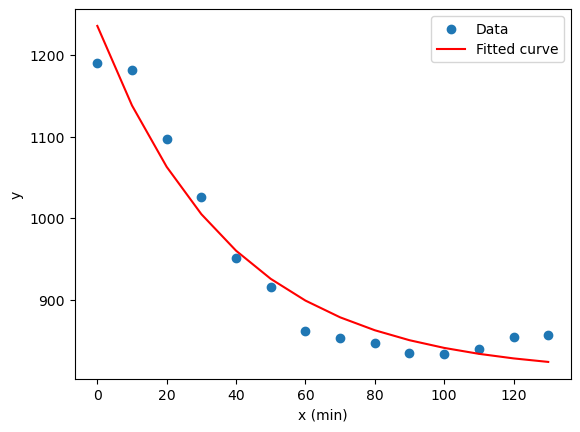

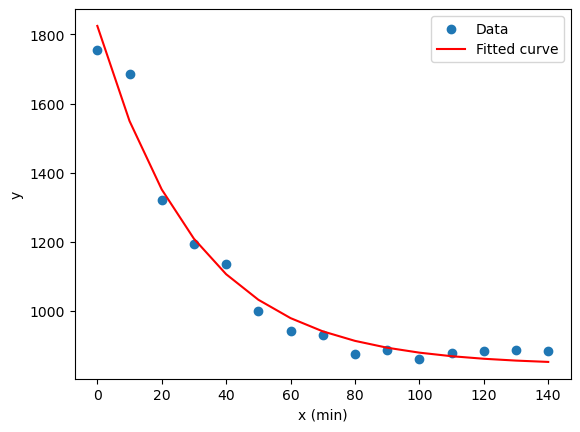

Not good parameters found


C:\Users\pperez\AppData\Local\Temp\1\ipykernel_20916\1851702164.py:2: RuntimeWarning: overflow encountered in multiply
  return y_min + (y_max - y_min) * np.exp(-b * x)


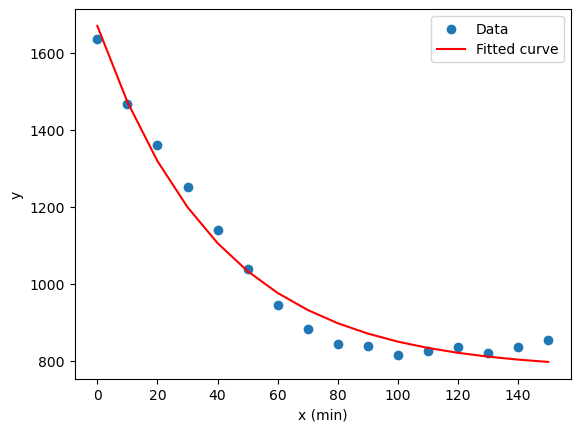

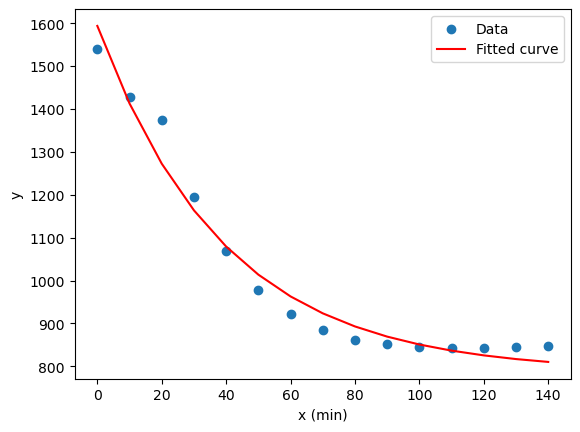

Not good parameters found


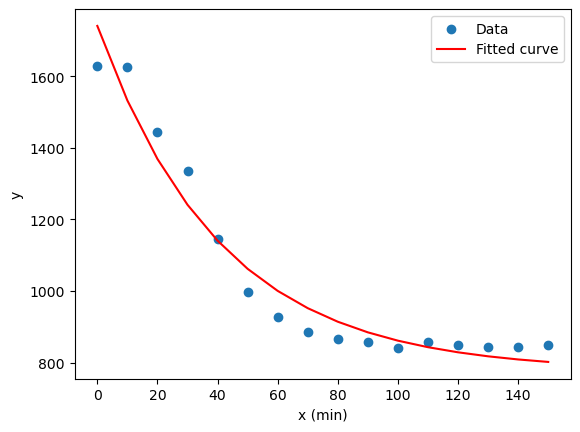

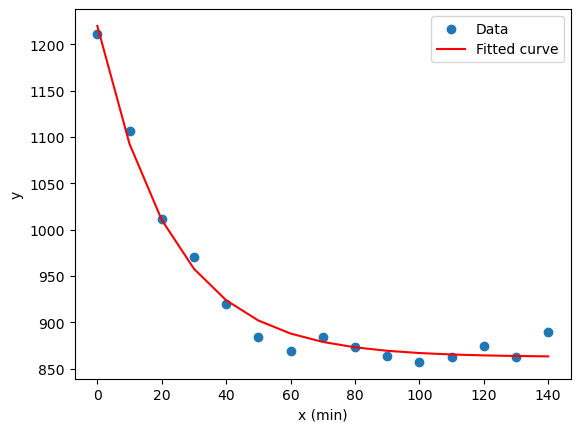

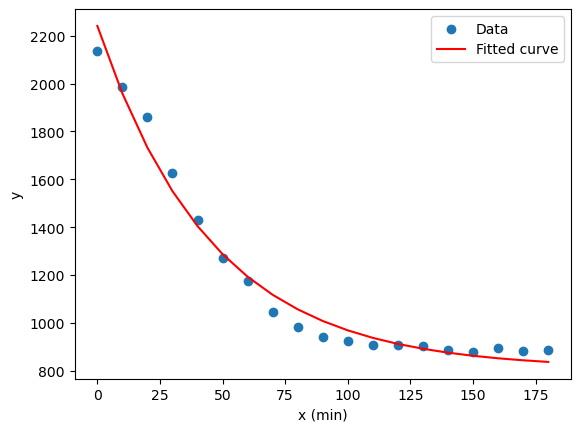

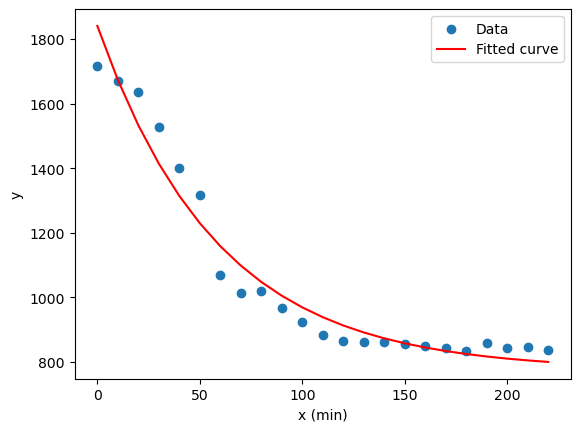

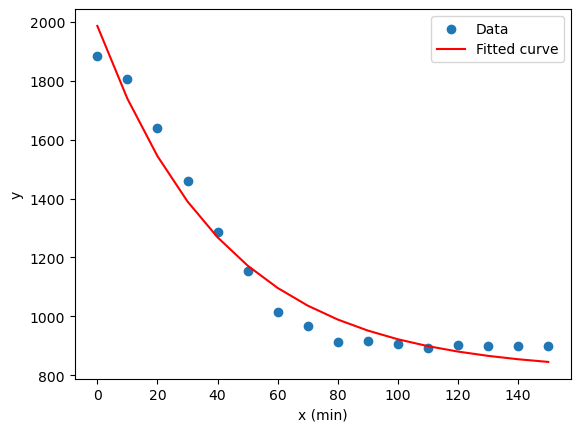

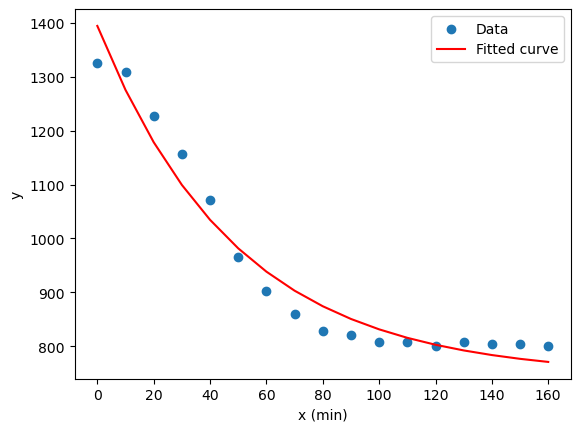

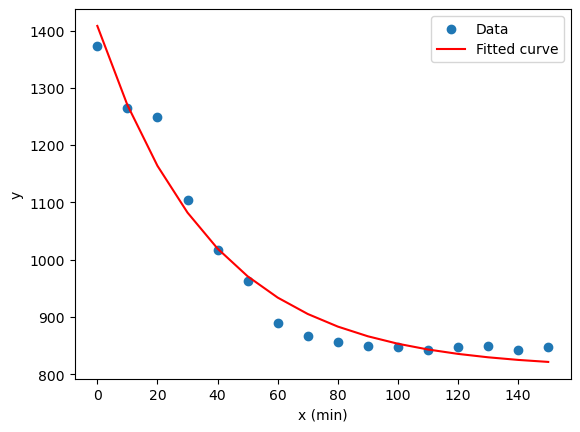

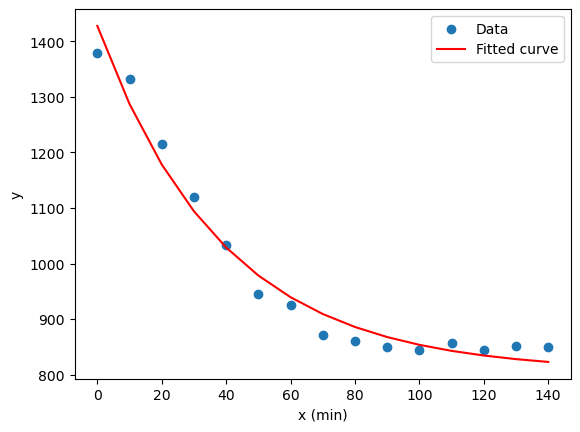

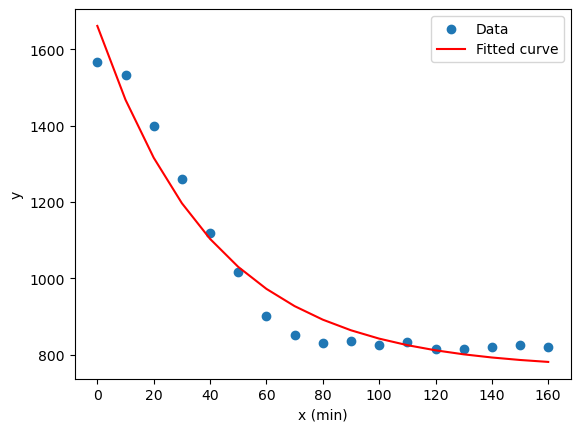

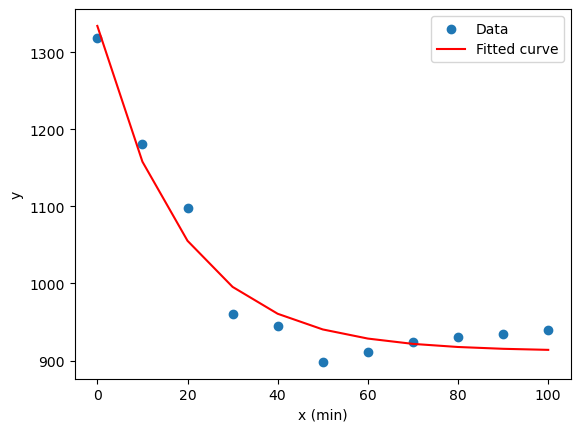

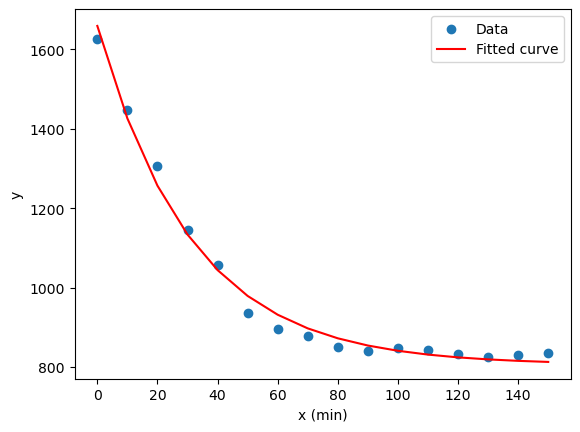

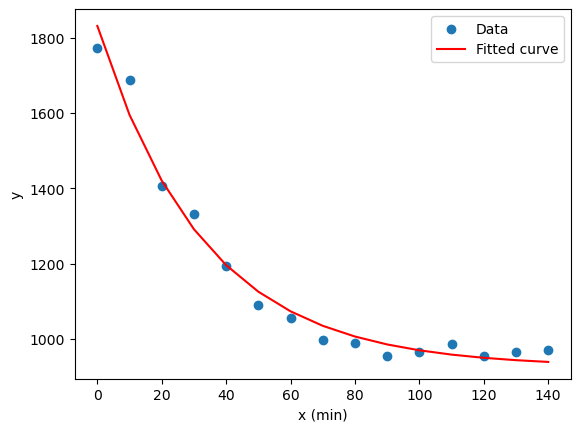

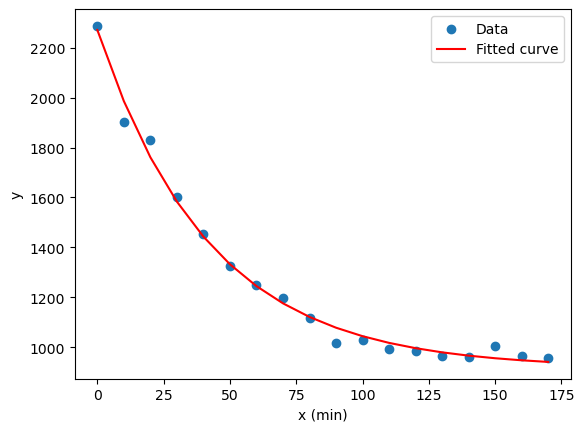

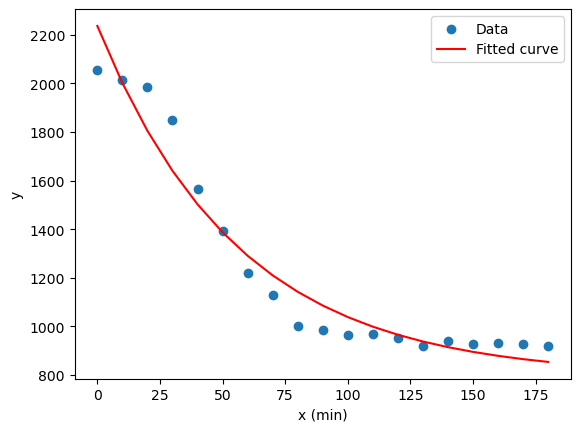

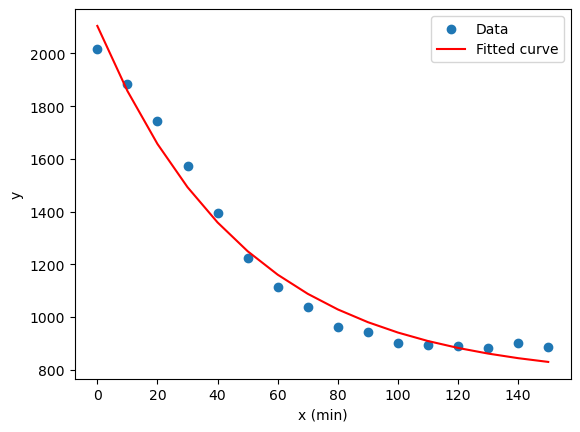

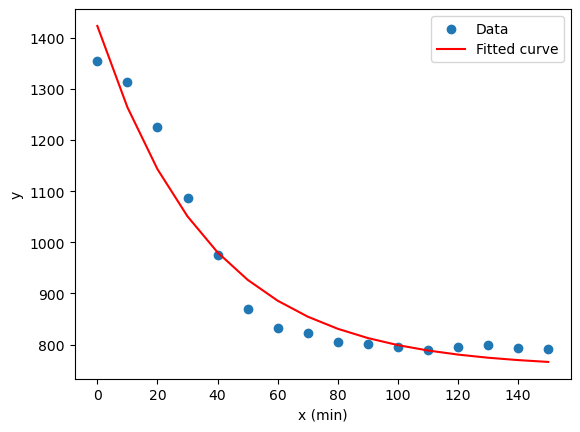

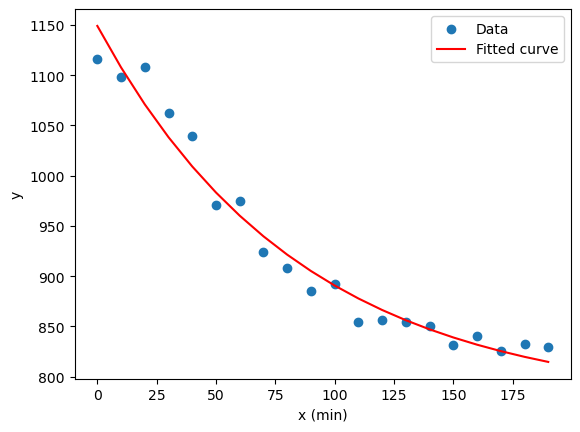

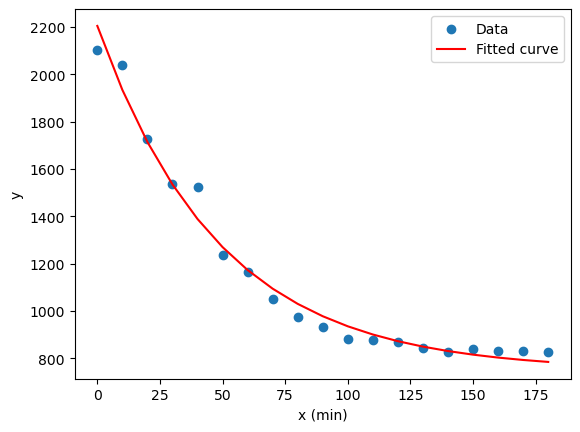

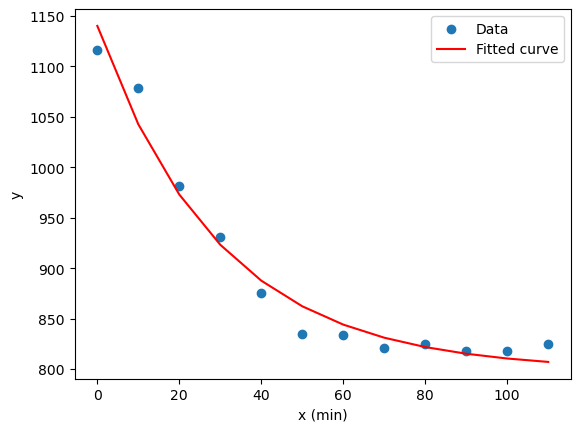

In [210]:
decay_list_control = []

for signal in signals_con_fit:
    y = get_points(signal, traces, trimmed)
    x = np.arange(0, len(y), 1)
    x_min = 10 * x
    initial_guess = [min(y), max(y), 1]
    try:
        params, covariance = curve_fit(modified_exponential_decay, x_min, y)
        plateau, peak_s, decay_rate = params
        decay_list_control.append(decay_rate)
        plt.scatter(x_min, y, label='Data')
        plt.plot(x_min, modified_exponential_decay(x_min, *params), label='Fitted curve', color='red')
        plt.xlabel('x (min)')
        plt.ylabel('y')
        plt.legend()
        plt.show()
    except RuntimeError:
        print('Not good parameters found')
    except TypeError:
        print('Not enough data')



    

C:\Users\pperez\AppData\Local\Temp\1\ipykernel_20916\1851702164.py:2: RuntimeWarning: overflow encountered in exp
  return y_min + (y_max - y_min) * np.exp(-b * x)


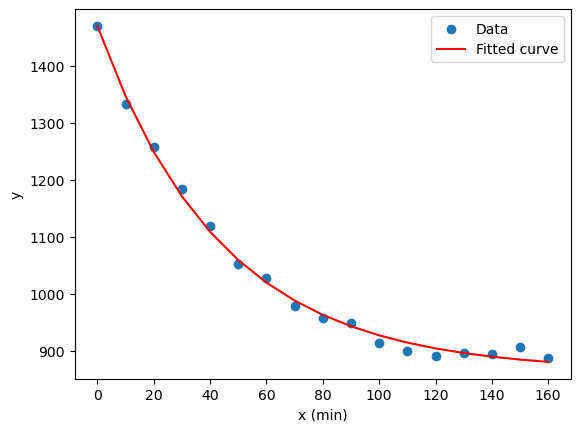

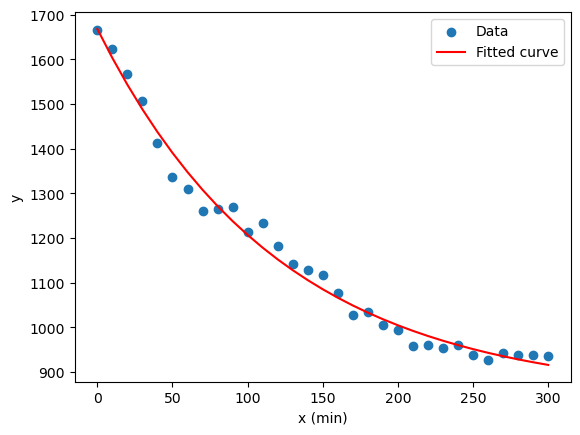

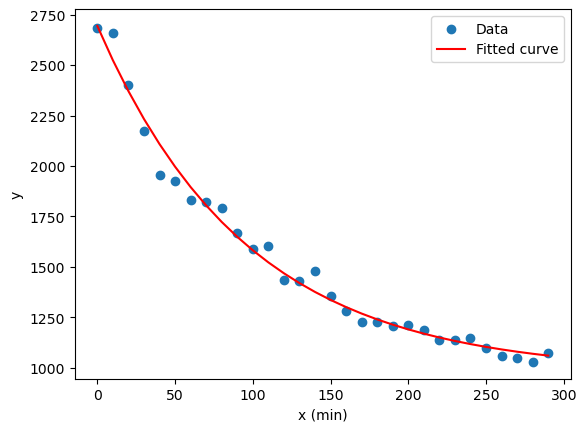

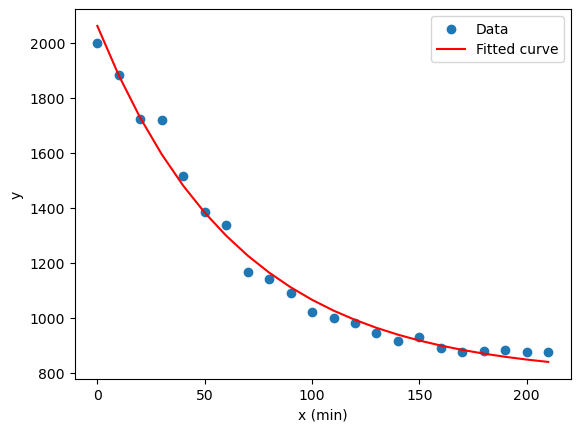

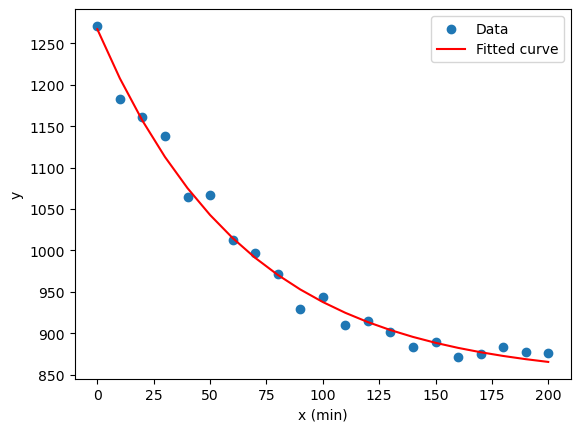

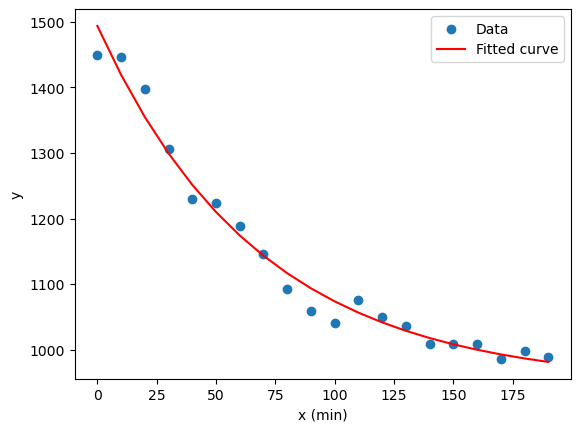

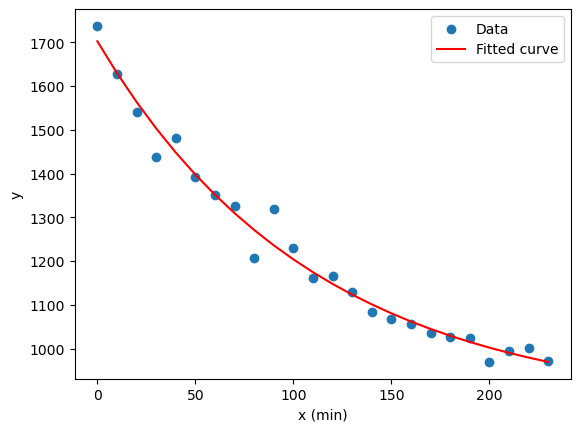

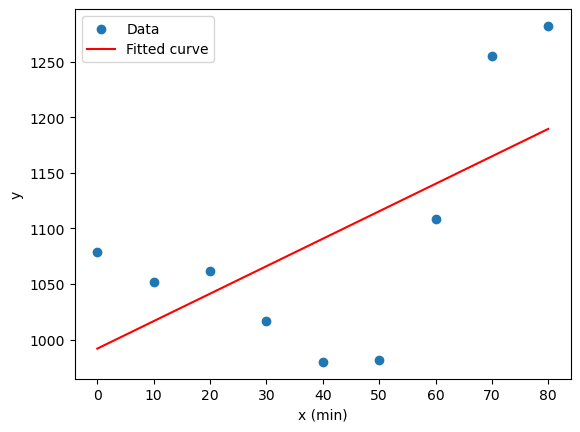

Not good parameters found


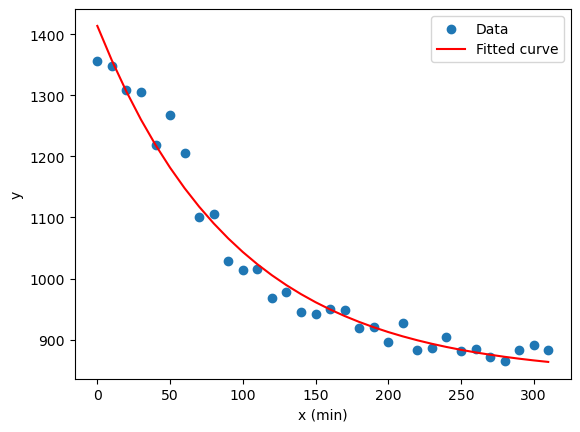

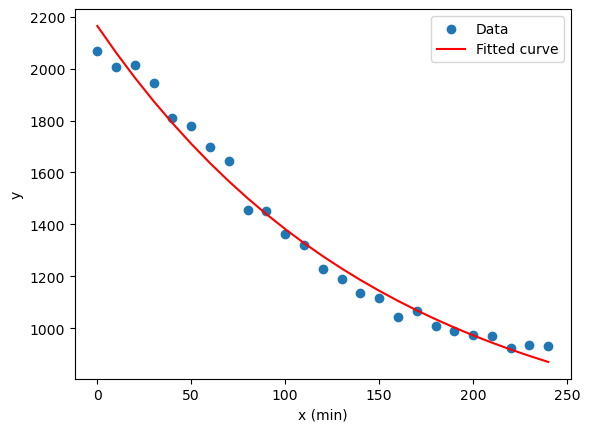

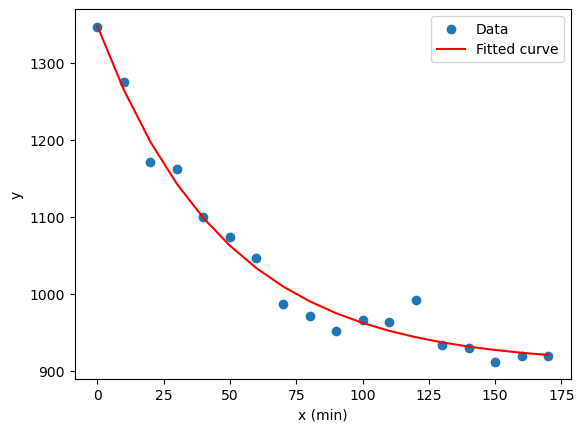

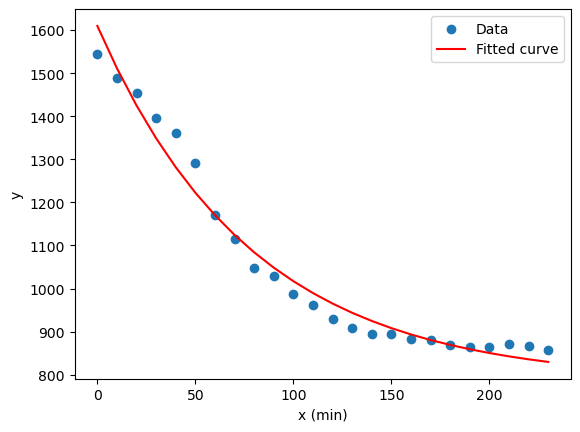

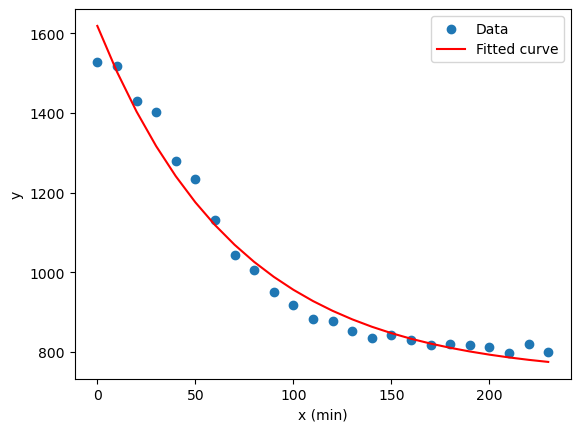

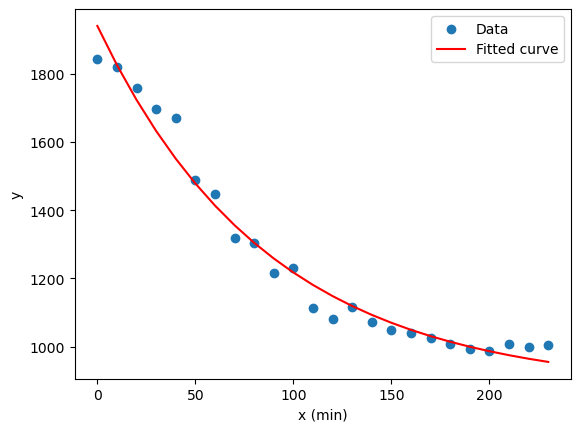

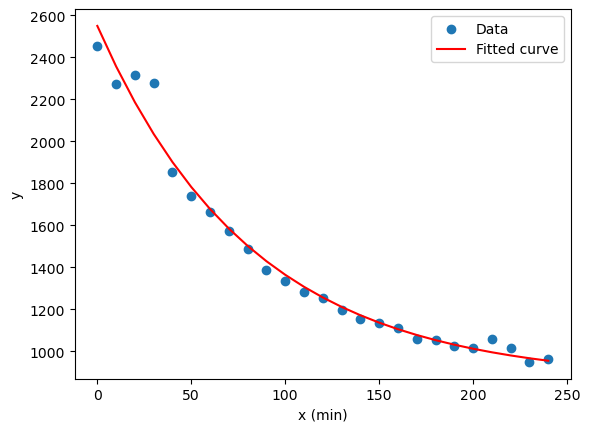

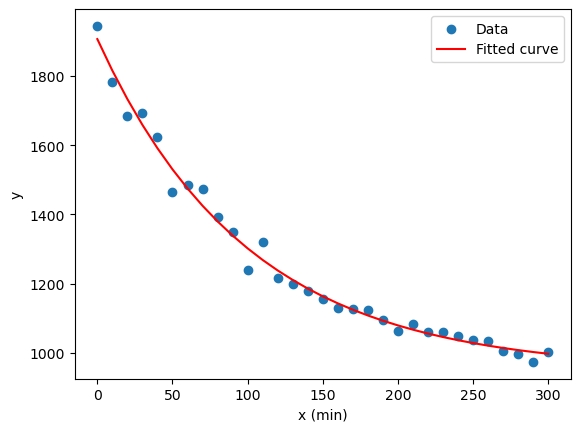

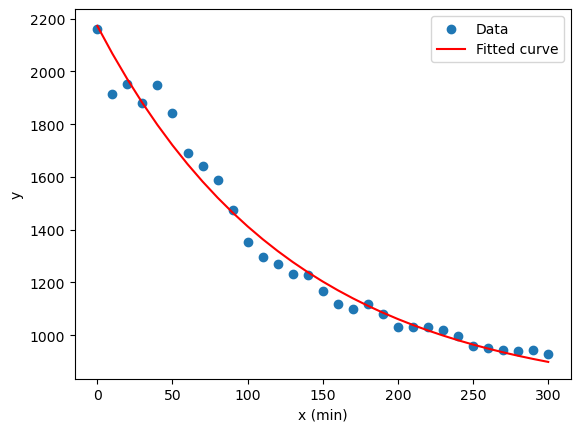

Not good parameters found


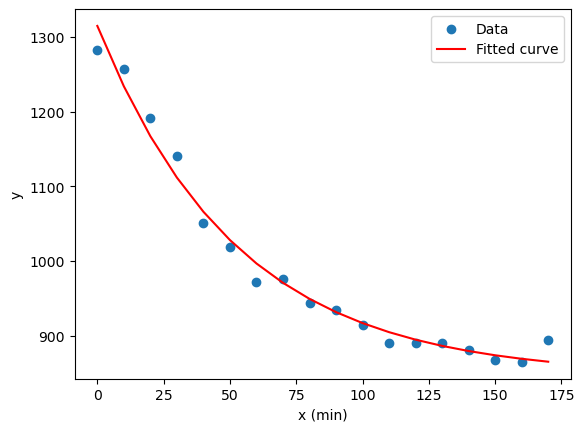

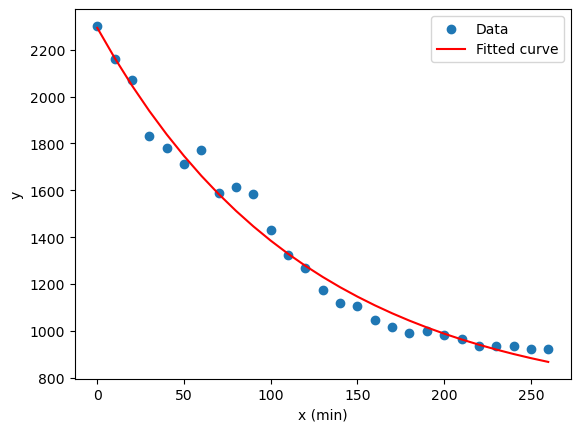

Not good parameters found


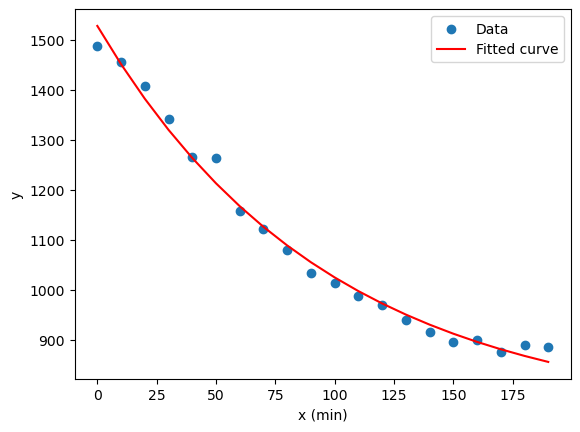

Not good parameters found


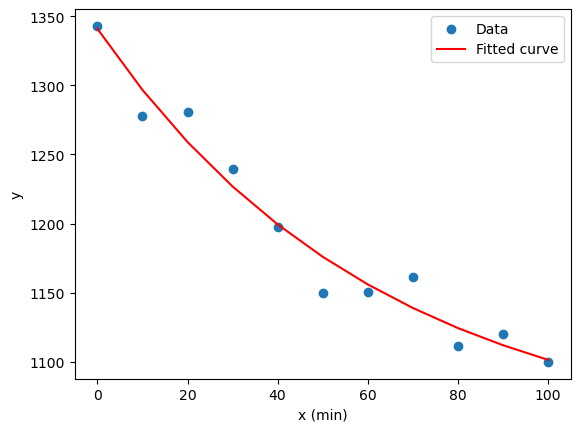

In [211]:
decay_list_50 = []

for signal in signals_50_fit:
    y = get_points(signal, traces, trimmed)
    x = np.arange(0, len(y), 1)
    x_min = 10 * x
    initial_guess = [min(y), max(y), 1]
    try:
        params, covariance = curve_fit(modified_exponential_decay, x_min, y)
        plateau, peak_s, decay_rate = params
        decay_list_50.append(decay_rate)
        plt.scatter(x_min, y, label='Data')
        plt.plot(x_min, modified_exponential_decay(x_min, *params), label='Fitted curve', color='red')
        plt.xlabel('x (min)')
        plt.ylabel('y')
        plt.legend()
        plt.show()
    except RuntimeError:
        print('Not good parameters found')
    except TypeError:
        print('Not enough data')

    

In [103]:
decay_l

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [103]:
decay_list = []
for signal in signals_con_fit:
    np.linspace()

[]

In [297]:
decay_control_df = pd.DataFrame(decay_list_control)
decay_control_df['Condition'] = 'Control'
decay_50_df = pd.DataFrame(decay_list_50)
decay_50_df['Condition'] = '50 nM'
decay_200_df = pd.DataFrame(decay_list_200)
decay_200_df['Condition'] = '200 nM'
decay_df = pd.concat([decay_control_df, decay_50_df, decay_200_df], ignore_index=True)

In [298]:
decay_df.rename(columns={0:'decay_rate'}, inplace=True)

In [299]:
p = bokeh_catplot.strip(
    data=decay_df,
    cats=['Condition'],
    val='decay_rate',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df,
    cats=['Condition'],
    val='decay_rate',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [386]:
p = bokeh_catplot.strip(
    data=decay_df_total,
    cats=['Experiment', 'Condition'],
    val='half-life',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df_total,
    cats=['Experiment', 'Condition'],
    val='half-life',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

p.output_backend = "svg"
# p.legend.title = 'Statistics'
# p.legend.location = 'top_right'
p.legend.label_text_font_size = '16pt'
p.xaxis.axis_label = 'her1-Venus half-life (min)'
p.xaxis.axis_label_text_font_size='16pt'
p.yaxis.major_label_text_font_size  = '16pt'
p.xaxis.major_label_text_font_size = '14pt'
export_svgs(p, filename="./half-life-200.svg")
bokeh.io.show(p)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\models\plots.py:815: UserWarning: 
You are attempting to set `plot.legend.label_text_font_size` on a plot that has zero legends added, this will have no effect.

Before legend properties can be set, you must add a Legend explicitly, or call a glyph method with a legend parameter set.

  warnings.warn(_LEGEND_EMPTY_WARNING % attr)
C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [303]:
p = bokeh_catplot.strip(
    data=decay_df_total,
    cats=['Condition', 'Experiment'],
    val='half-life',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df_total,
    cats=['Condition', 'Experiment'],
    val='half-life',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

bokeh.io.show(p)

RuntimeError: half-life is not a column in the inputted data frame

In [301]:
decay_df['Experiment'] = 'ppf019'

In [296]:
decay_df_ppf018 = pd.read_csv('./decay_rates_ppf018', index_col=0)

In [302]:
decay_df_total = pd.concat([decay_df_ppf018, decay_df], ignore_index=True)

In [251]:
p = bokeh_catplot.strip(
    data=decay_df_total,
    cats=['Condition'],
    val='half-life',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df_total,
    cats=['Condition'],
    val='half-life',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [240]:
np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].std(ddof=1)

7.195474597498378

In [239]:
np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'decay_rate'].std(ddof=1)

17.527691502723034

In [304]:
decay_df_total['half-life'] = np.log(2)/decay_df_total['decay_rate']

In [245]:
decay_df_total['half-life'].max()

198095.18056149216

In [308]:
max_index = decay_df_total['half-life'].idxmin()

In [309]:
decay_df_total = decay_df_total.drop(max_index)

In [280]:
decay_df_total.loc[decay_df_total['Condition'] == '50 nM','half-life'].mean()

48.7744090292086

In [259]:
np.log(2)/(decay_df_total.loc[decay_df_total['Condition'] == 'Control','decay_rate'].mean())

24.60151802479442

In [261]:
decay_df_total.loc[decay_df_total['Condition'] == 'Control','half-life'].mean()

In [400]:
decay_df_total['Drug'] = 'MG132'

In [401]:
decay_df_total.drop('Condition_Experiment', axis=1).to_csv('./MG132_decay_rates')

ERROR:tornado.application:Uncaught exception GET /autoload.js?bokeh-autoload-element=1270&bokeh-absolute-url=http://localhost:64160&resources=none (::1)
HTTPServerRequest(protocol='http', host='localhost:64160', method='GET', uri='/autoload.js?bokeh-autoload-element=1270&bokeh-absolute-url=http://localhost:64160&resources=none', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "C:\Users\pperez\AppData\Roaming\Python\Python39\site-packages\tornado\web.py", line 1790, in _execute
    result = await result
  File "C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\server\views\autoload_js_handler.py", line 62, in get
    session = await self.get_session()
  File "C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\server\views\session_handler.py", line 144, in get_session
    session = await self.application_context.create_session_if_needed(session_id, self.request, token)
  File "C:\Users\pperez\.conda\envs\devbio-napar

In [387]:
import bokeh.io
import pandas as pd
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap, jitter
from bokeh.palettes import Category10

# Sample DataFrame for demonstration

# Get unique values in the 'Experiment' column for coloring
experiments = list(decay_df_total['Experiment'].unique())

# Ensure we have at least 2 colors in the palette
palette = Category10[10][:2]  # Get the first two colors from Category10

# Create a color mapper based on the 'Experiment' column
color_mapper = factor_cmap('Experiment', palette=palette, factors=experiments)

# Create a ColumnDataSource
source = ColumnDataSource(decay_df_total)

# Create the figure
p = figure(x_range=list(decay_df_total['Condition'].unique()), height=650, width=850, title="Strip Plot")

# Add strip plot points
p.circle(
   x='half-life', y=jitter('Condition', width=0.3, range=p.y_range),  source=source,
    size=10, color=color_mapper, alpha=0.8, legend_field='Experiment'
)


# Show the plot
show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [397]:

# Create a combined column for "Condition" and "Experiment"
# decay_df_total['Condition_Experiment'] = decay_df_total['Condition'] + "_" + decay_df_total['Experiment']

# Get unique values in the 'Condition_Experiment' column for coloring
decay_df_total['Condition_Experiment'] = decay_df_total['Condition'] + "_" + decay_df_total['Experiment']
condition_experiment_combinations = list(decay_df_total['Condition_Experiment'].unique())

# Create a color mapper based on the 'Condition_Experiment' column
palette = Category20[len(condition_experiment_combinations)-1]  # Get a palette with enough colors
color_mapper = factor_cmap('Condition_Experiment', palette=palette, factors=condition_experiment_combinations)

# Create a ColumnDataSource
source = ColumnDataSource(decay_df_total.loc[(decay_df_total['Condition'] == 'Control') | (decay_df_total['Condition'] == '50 nM'), :])

# Create the figure
p = figure(y_range=list(decay_df_total.loc[(decay_df_total['Condition'] == 'Control') | (decay_df_total['Condition'] == '50 nM'), 'Condition'].unique()), height=650, width=850, title="Half-life in different experiments")

# Add strip plot points with jitter
p.circle(
    x='half-life', y=jitter('Condition', width=0.3, range=p.y_range), source=source,
    size=10, color=color_mapper, alpha=0.9, legend_field='Condition_Experiment'
)

# Show the plot
p.output_backend = "svg"
# p.legend.title = 'Statistics'
# p.legend.location = 'top_right'
p.legend.label_text_font_size = '16pt'
p.xaxis.axis_label = 'her1-Venus half-life (min)'
p.xaxis.axis_label_text_font_size='16pt'
p.yaxis.major_label_text_font_size  = '16pt'
p.xaxis.major_label_text_font_size = '14pt'
export_svgs(p, filename="./half-life-dif-exp.svg")
bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


ERROR:tornado.application:Uncaught exception GET /autoload.js?bokeh-autoload-element=1270&bokeh-absolute-url=http://localhost:64160&resources=none (::1)
HTTPServerRequest(protocol='http', host='localhost:64160', method='GET', uri='/autoload.js?bokeh-autoload-element=1270&bokeh-absolute-url=http://localhost:64160&resources=none', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "C:\Users\pperez\AppData\Roaming\Python\Python39\site-packages\tornado\web.py", line 1790, in _execute
    result = await result
  File "C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\server\views\autoload_js_handler.py", line 62, in get
    session = await self.get_session()
  File "C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\server\views\session_handler.py", line 144, in get_session
    session = await self.application_context.create_session_if_needed(session_id, self.request, token)
  File "C:\Users\pperez\.conda\envs\devbio-napar

C:\Users\pperez\AppData\Local\Temp\1\ipykernel_20916\1851702164.py:2: RuntimeWarning: overflow encountered in exp
  return y_min + (y_max - y_min) * np.exp(-b * x)


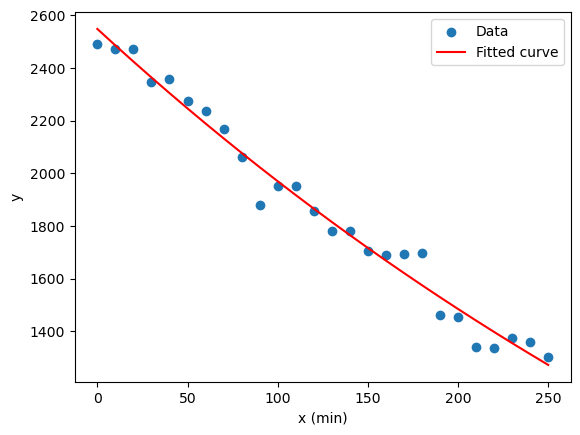

Not enough data


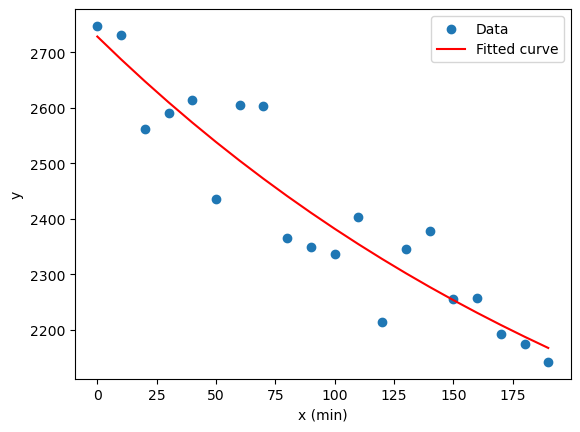

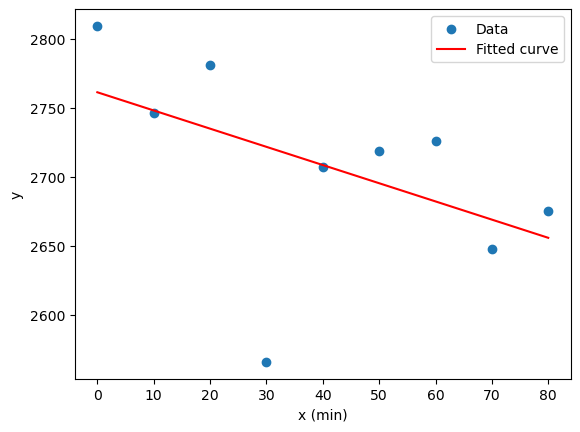

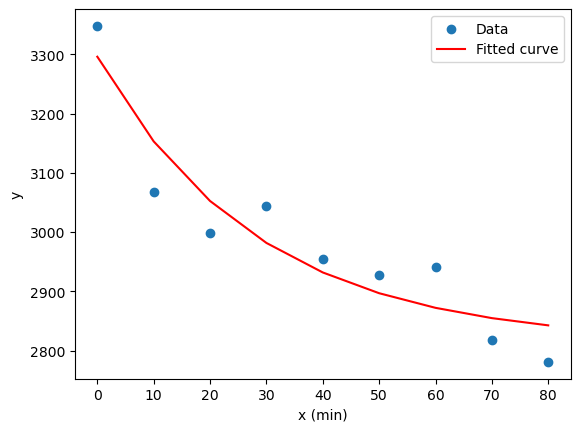

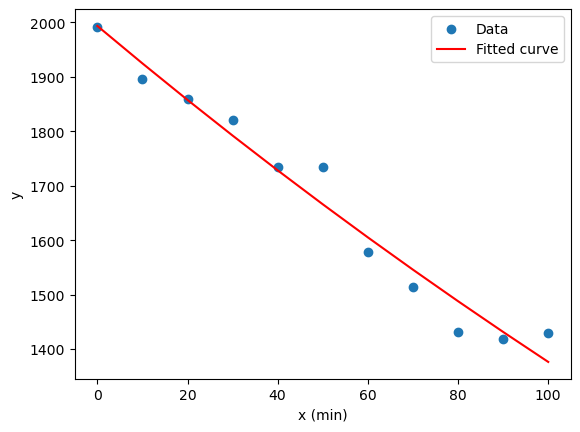

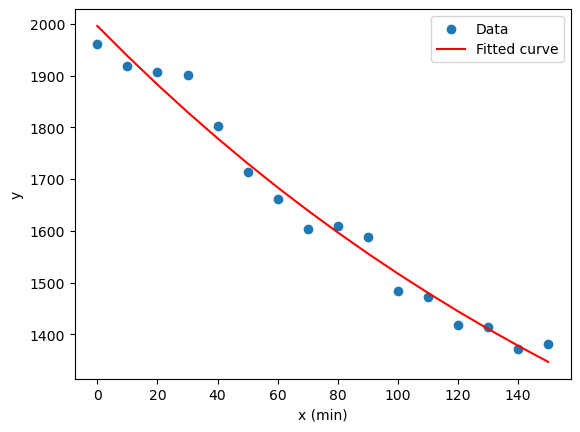

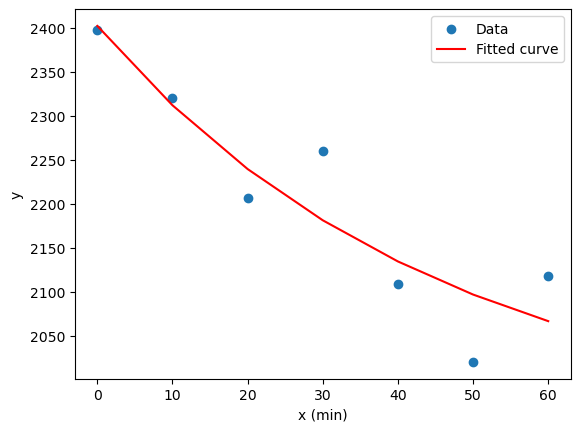

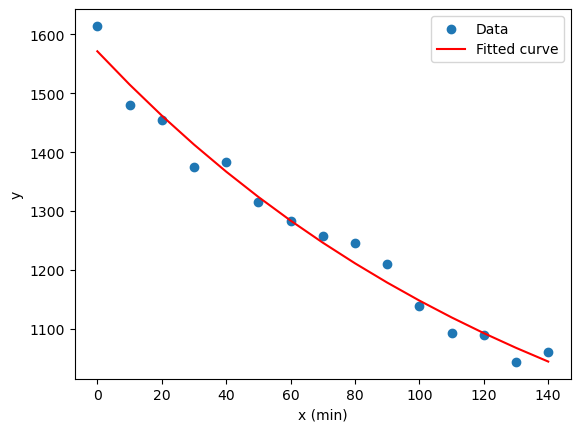

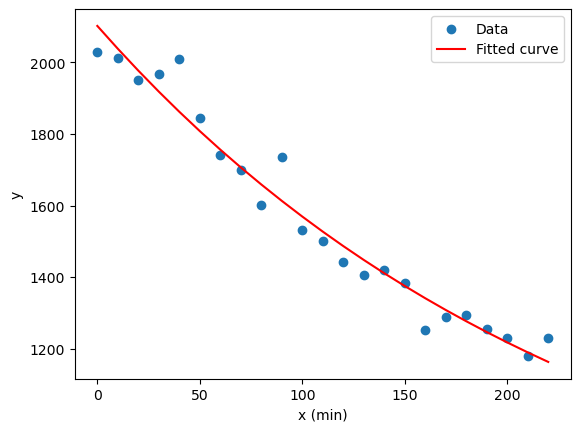

C:\Users\pperez\AppData\Local\Temp\1\ipykernel_20916\1851702164.py:2: RuntimeWarning: overflow encountered in multiply
  return y_min + (y_max - y_min) * np.exp(-b * x)


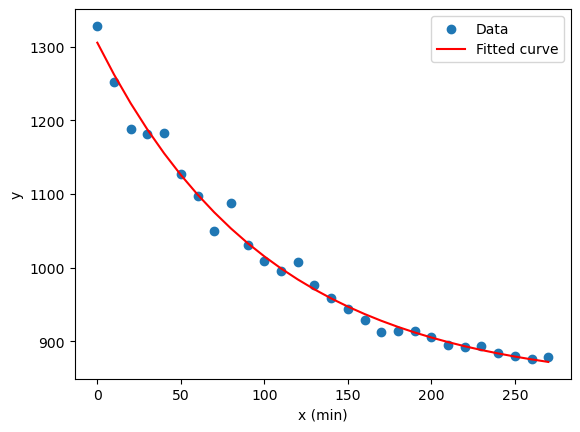

In [292]:
def get_points(signal, traces, trimmed):
    peak = int(trimmed.loc[trimmed['Signal']==signal, 'Peak pos'].max())
    eo = int(trimmed.loc[trimmed['Signal']==signal, 'End of oscillation'].max())
    points = traces[signal][peak:eo+1]
    return points

decay_list_200 = []
signals_200_fit =  trimmed.loc[(trimmed['Condition'] == '200 nM'), 'Signal'].unique()
for signal in signals_200_fit:
    y = get_points(signal, traces, trimmed)
    x = np.arange(0, len(y), 1)
    x_min = 10 * x
    initial_guess = [min(y), max(y), 1]
    try:
        params, covariance = curve_fit(modified_exponential_decay, x_min, y)
        plateau, peak_s, decay_rate = params
        decay_list_200.append(decay_rate)
        plt.scatter(x_min, y, label='Data')
        plt.plot(x_min, modified_exponential_decay(x_min, *params), label='Fitted curve', color='red')
        plt.xlabel('x (min)')
        plt.ylabel('y')
        plt.legend()
        plt.show()
    except RuntimeError:
        print('Not good parameters found')
    except TypeError:
        print('Not enough data')


In [383]:
p = bokeh_catplot.strip(
    data=decay_df_total.loc[(decay_df_total['Condition'] == 'Control') | (decay_df_total['Condition'] == '50 nM'), :],
    cats=['Condition'],
    val='half-life',
    horizontal=False,
    jitter=True,
    height=650,
    width=850,
    x_range=(0, decay_df_total.loc[decay_df_total['Condition'] == '50 nM', 'half-life'].max()+5),
    marker_kwargs=dict(size=6,alpha=0.8)    # tooltips=[('Position', '@{Cell_position}'),
    #          ('Period', '@{Max. power period (min)}')]
    
)

p = bokeh_catplot.box(
    data=decay_df_total.loc[(decay_df_total['Condition'] == 'Control') | (decay_df_total['Condition'] == '50 nM'), :],
    cats=['Condition'],
    val='half-life',
    horizontal=False,
    whisker_caps=True,
    display_points=False,
    box_kwargs=dict(fill_color=None, line_color='gray'),
    median_kwargs=dict(line_color='gray'),
    whisker_kwargs=dict(line_color='gray'),
    height=650,
    width=850,
    p=p,
)

mean_control = np.log(2)/(decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].mean())
median_control = np.log(2)/decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].median()
std_control = np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='Control', 'decay_rate'].std(ddof=1)

mean_50 = np.log(2)/(decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'decay_rate'].mean())
median_50 = np.log(2)/decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'decay_rate'].median()
std_50 = np.log(2)/(np.square(decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'decay_rate'].mean())) * decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'decay_rate'].std(ddof=1)

p.circle([], [], legend_label=f"Control:")
p.circle([], [], legend_label=f"Total signals: {len(decay_df_total.loc[decay_df_total['Condition']=='Control', 'half-life'])}")
p.circle([], [], legend_label=f"Mean: {mean_control:.0f} min")
p.circle([], [], legend_label=f"Mean: {median_control:.0f} min")
p.circle([], [], legend_label=f"Std: {std:.0f} min",)

p.circle([], [], legend_label=f"------")

p.circle([], [], legend_label=f"50 nM MG132:")
p.circle([], [], legend_label=f"Total signals: {len(decay_df_total.loc[decay_df_total['Condition']=='50 nM', 'half-life'])}")
p.circle([], [], legend_label=f"Mean: {mean_50:.0f} min")
p.circle([], [], legend_label=f"Median: {median_50:.0f} min")
p.circle([], [], legend_label=f"Std: {std_50:.0f} min")

p.output_backend = "svg"
p.legend.title = 'Statistics'
p.legend.location = 'top_right'
p.legend.label_text_font_size = '12pt'
p.xaxis.axis_label = 'her1-Venus half-life (min)'
p.xaxis.axis_label_text_font_size='16pt'
p.xaxis.major_label_text_font_size = '14pt'
p.yaxis.major_label_text_font_size  = '16pt'
export_svgs(p, filename="./half-life.svg")
bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)


In [343]:
from bokeh.io.export import export_png, export_svgs

In [385]:
p = iqplot.ecdf(
    data=decay_df_total.loc[decay_df_total['Condition'] == 'Control',:],
    q="half-life",
    cats=['Condition'],
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][0],
    tooltips=[('Experiment', '@{Experiment}')],
    height=800,
    width=800,
    x_range=(0, decay_df_total.loc[decay_df_total['Condition'] == '50 nM', 'half-life'].max()+5),
    y_range=(0, 1.4),
    marker_kwargs=dict(size=6, alpha=0.8)
)

p = iqplot.ecdf(
    data=decay_df_total.loc[decay_df_total['Condition'] == '50 nM',:],
    q="half-life",
    cats=['Condition'],
    kind='colored',
    palette=bokeh.palettes.d3['Category20'][5][2],
    tooltips=[('Experiment', '@{Experiment}')],
    marker_kwargs=dict(size=6, alpha=0.8),
    p=p
)

p.output_backend = "svg"
# p.legend.title = 'Statistics'
# p.legend.location = 'top_right'
p.legend.label_text_font_size = '16pt'
p.xaxis.axis_label = 'her1-Venus half-life (min)'
p.xaxis.axis_label_text_font_size='16pt'
p.yaxis.major_label_text_font_size  = '16pt'
p.xaxis.major_label_text_font_size = '14pt'
export_svgs(p, filename="./half-life_ecdf.svg")
bokeh.io.show(p)

C:\Users\pperez\.conda\envs\devbio-napari-cupy\lib\site-packages\bokeh\io\notebook.py:487: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  publish_display_data(data, metadata, source, transient=transient, **kwargs)
